# Medical Data Clustering Using Self-Organizing Maps (SOM)
## Phase 1 - Dataset Loading & Exploratory Data Analysis (EDA)

**B.Tech Neural Networks Course Project**

> **Dataset:** Breast Cancer Wisconsin (Diagnostic) - UCI ML Repository (ID: 17)
> **Goal:** Load the dataset, inspect its structure, and visualize key patterns.
> **Note:** Diagnosis labels (M/B) are observed here for EDA context only - they are NEVER used in ML training.

## 0. Imports & Setup

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = {'B': '#2ecc71', 'M': '#e74c3c'}  # green=Benign, red=Malignant

FIGURES_DIR = os.path.join('..', '..', 'results', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print('All imports successful')
print(f'Figures will be saved to: {os.path.abspath(FIGURES_DIR)}')

All imports successful
Figures will be saved to: C:\Users\Harsh Seth\OneDrive\Documents\NN MEDICAL SOM\medical-som-clustering\results\figures


## 1. Load Dataset

Fetching from UCI ML Repository (ID = 17) using ucimlrepo.

In [2]:
# ── Robust loading: UCI first, local wdbc.data fallback ────────────
WDBC_DATA_PATH = os.path.join('..', '..', '..', 'wdbc.data')  # local raw file
LOCAL_CSV_PATH = os.path.join('..', 'data', 'breast_cancer.csv')

# Column names per wdbc.names: ID, Diagnosis, then 30 features
FEATURE_NAMES = [
    'radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean',
    'compactness_mean','concavity_mean','concave points_mean','symmetry_mean','fractal_dimension_mean',
    'radius_se','texture_se','perimeter_se','area_se','smoothness_se',
    'compactness_se','concavity_se','concave points_se','symmetry_se','fractal_dimension_se',
    'radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst',
    'compactness_worst','concavity_worst','concave points_worst','symmetry_worst','fractal_dimension_worst'
]

breast_cancer = None
load_source = None

# ── Try 1: ucimlrepo (internet) ─────────────────────────────────────
try:
    from ucimlrepo import fetch_ucirepo
    breast_cancer = fetch_ucirepo(id=17)
    X = breast_cancer.data.features
    y = breast_cancer.data.targets
    load_source = 'ucimlrepo (online)'
    print('Loaded via ucimlrepo (internet).')
except Exception as e1:
    print(f'ucimlrepo failed ({e1}). Trying local wdbc.data ...')
    # ── Try 2: local wdbc.data ───────────────────────────────────────
    try:
        raw = pd.read_csv(WDBC_DATA_PATH, header=None,
                          names=['id', 'Diagnosis'] + FEATURE_NAMES)
        X = raw[FEATURE_NAMES].copy()
        y = raw[['Diagnosis']].copy()
        load_source = 'local wdbc.data'
        print('Loaded via local wdbc.data.')
    except Exception as e2:
        raise FileNotFoundError(
            f'Both loading methods failed.\n  ucimlrepo: {e1}\n  local: {e2}'
        )

# ── Save / refresh local CSV backup ─────────────────────────────────
csv_df = X.copy()
csv_df.insert(0, 'Diagnosis', np.asarray(y['Diagnosis'].values))
csv_df.to_csv(LOCAL_CSV_PATH, index=False)

print(f'Load source  : {load_source}')
print(f'Local CSV    : {os.path.abspath(LOCAL_CSV_PATH)}')
print(f'Dataset shape: X={X.shape}, y={y.shape}')

Loaded via ucimlrepo (internet).
Load source  : ucimlrepo (online)
Local CSV    : C:\Users\Harsh Seth\OneDrive\Documents\NN MEDICAL SOM\medical-som-clustering\ml\data\breast_cancer.csv
Dataset shape: X=(569, 30), y=(569, 1)


## 2. Dataset Shape

Expected: **569 samples x 30 features**.

In [3]:
print('=' * 50)
print('DATASET DIMENSIONS')
print('=' * 50)
print(f'  Feature matrix X : {X.shape}   (samples x features)')
print(f'  Target vector  y : {y.shape}   (samples x 1)')
print(f'  Samples  : {X.shape[0]}')
print(f'  Features : {X.shape[1]}')

DATASET DIMENSIONS
  Feature matrix X : (569, 30)   (samples x features)
  Target vector  y : (569, 1)   (samples x 1)
  Samples  : 569
  Features : 30


## 3. First 5 Rows

In [4]:
print('First 5 rows of feature matrix X:')
X.head()

First 5 rows of feature matrix X:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Feature Names

All 30 features are grouped into **Mean**, **Standard Error (SE)**, and **Worst** for 10 base measurements.

In [5]:
features = X.columns.tolist()
print(f'Total features: {len(features)}')

groups = [('Mean (1-10)', features[:10]), ('Standard Error (11-20)', features[10:20]), ('Worst (21-30)', features[20:])]
for group_name, group_feats in groups:
    print(f'\n  [{group_name}]')
    for i, f in enumerate(group_feats, 1):
        print(f'    {i:2d}. {f}')

Total features: 30

  [Mean (1-10)]
     1. radius1
     2. texture1
     3. perimeter1
     4. area1
     5. smoothness1
     6. compactness1
     7. concavity1
     8. concave_points1
     9. symmetry1
    10. fractal_dimension1

  [Standard Error (11-20)]
     1. radius2
     2. texture2
     3. perimeter2
     4. area2
     5. smoothness2
     6. compactness2
     7. concavity2
     8. concave_points2
     9. symmetry2
    10. fractal_dimension2

  [Worst (21-30)]
     1. radius3
     2. texture3
     3. perimeter3
     4. area3
     5. smoothness3
     6. compactness3
     7. concavity3
     8. concave_points3
     9. symmetry3
    10. fractal_dimension3


## 5. Data Types

In [6]:
print('Data types of features:')
print(X.dtypes)
print()
all_float = all(X.dtypes == 'float64')
print(f'All features numeric (float64): {all_float}')

Data types of features:
radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3       float64
symmetry3             float64
fractal_dimension3    float64
dtype: object

All features numeric (float64): True


## 6. Missing Values

The WDBC dataset is documented to have no missing values. We confirm explicitly.

In [7]:
missing = X.isnull().sum()
total_missing = missing.sum()
print(f'Total missing values in X: {total_missing}')
if total_missing == 0:
    print('  No missing values found - dataset is complete.')
else:
    print('  Missing values detected:')
    print(missing[missing > 0])

Total missing values in X: 0
  No missing values found - dataset is complete.


## 7. Duplicate Rows

In [8]:
n_dup = X.duplicated().sum()
print(f'Duplicate rows in X: {n_dup}')
if n_dup == 0:
    print('  No duplicate rows found.')
else:
    print(f'  {n_dup} duplicate row(s) detected.')

Duplicate rows in X: 0
  No duplicate rows found.


## 8. Diagnosis / Class Distribution

Count of Benign (B) vs Malignant (M) samples. Labels observed here for EDA only.

In [9]:
dist = y['Diagnosis'].value_counts()
dist_pct = y['Diagnosis'].value_counts(normalize=True) * 100

print('Class Distribution:')
print('-' * 40)
for label in ['B', 'M']:
    name = 'Benign' if label == 'B' else 'Malignant'
    print(f'  {label} ({name}): {dist[label]}  ({dist_pct[label]:.1f}%)')
print('-' * 40)
print(f'  Total: {len(y)}')

Class Distribution:
----------------------------------------
  B (Benign): 357  (62.7%)
  M (Malignant): 212  (37.3%)
----------------------------------------
  Total: 569


## 9. Descriptive Statistics

Note the wide variation in scale - this is why **StandardScaler** is mandatory before SOM training.

In [10]:
from IPython.display import display
stats = X.describe().T
stats['range'] = stats['max'] - stats['min']
print('Descriptive Statistics (transposed):')
display(stats[['count', 'mean', 'std', 'min', 'max', 'range']].round(4))

Descriptive Statistics (transposed):


,count,mean,std,min,max,range
radius1,569.0,14.1273,3.5240,6.9810,28.1100,21.1290
texture1,569.0,19.2896,4.3010,9.7100,39.2800,29.5700
perimeter1,569.0,91.9690,24.2990,43.7900,188.5000,144.7100
area1,569.0,654.8891,351.9141,143.5000,2501.0000,2357.5000
smoothness1,569.0,0.0964,0.0141,0.0526,0.1634,0.1108
compactness1,569.0,0.1043,0.0528,0.0194,0.3454,0.3260
concavity1,569.0,0.0888,0.0797,0.0000,0.4268,0.4268
concave_points1,569.0,0.0489,0.0388,0.0000,0.2012,0.2012
symmetry1,569.0,0.1812,0.0274,0.1060,0.3040,0.1980
fractal_dimension1,569.0,0.0628,0.0071,0.0500,0.0974,0.0475


## 10. Diagnosis Distribution Plot

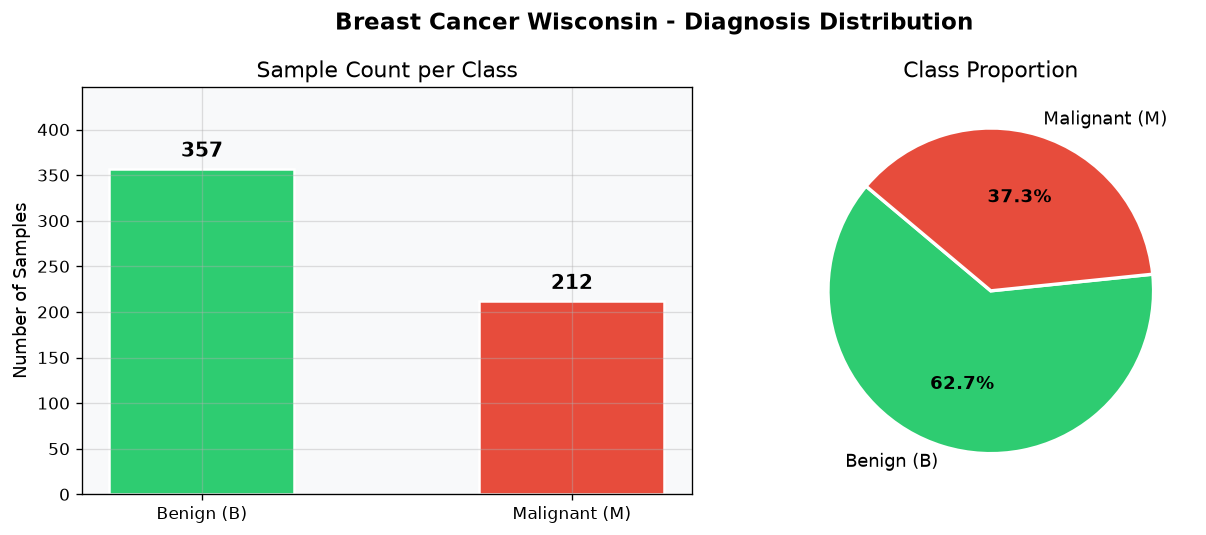

Figure saved: ..\..\results\figures\01_diagnosis_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Breast Cancer Wisconsin - Diagnosis Distribution', fontsize=14, fontweight='bold')

labels = ['Benign (B)', 'Malignant (M)']
counts = [dist['B'], dist['M']]
colors = ['#2ecc71', '#e74c3c']

ax1 = axes[0]
bars = ax1.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax1.set_title('Sample Count per Class')
ax1.set_ylabel('Number of Samples')
ax1.set_ylim(0, max(counts) * 1.25)
for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             str(cnt), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Class Proportion')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '01_diagnosis_distribution.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Figure saved: {fig_path}')

## 11. Feature Distribution Visualization

Histograms of all 30 features, colour-coded by diagnosis. Reveals which features separate Benign/Malignant most clearly.

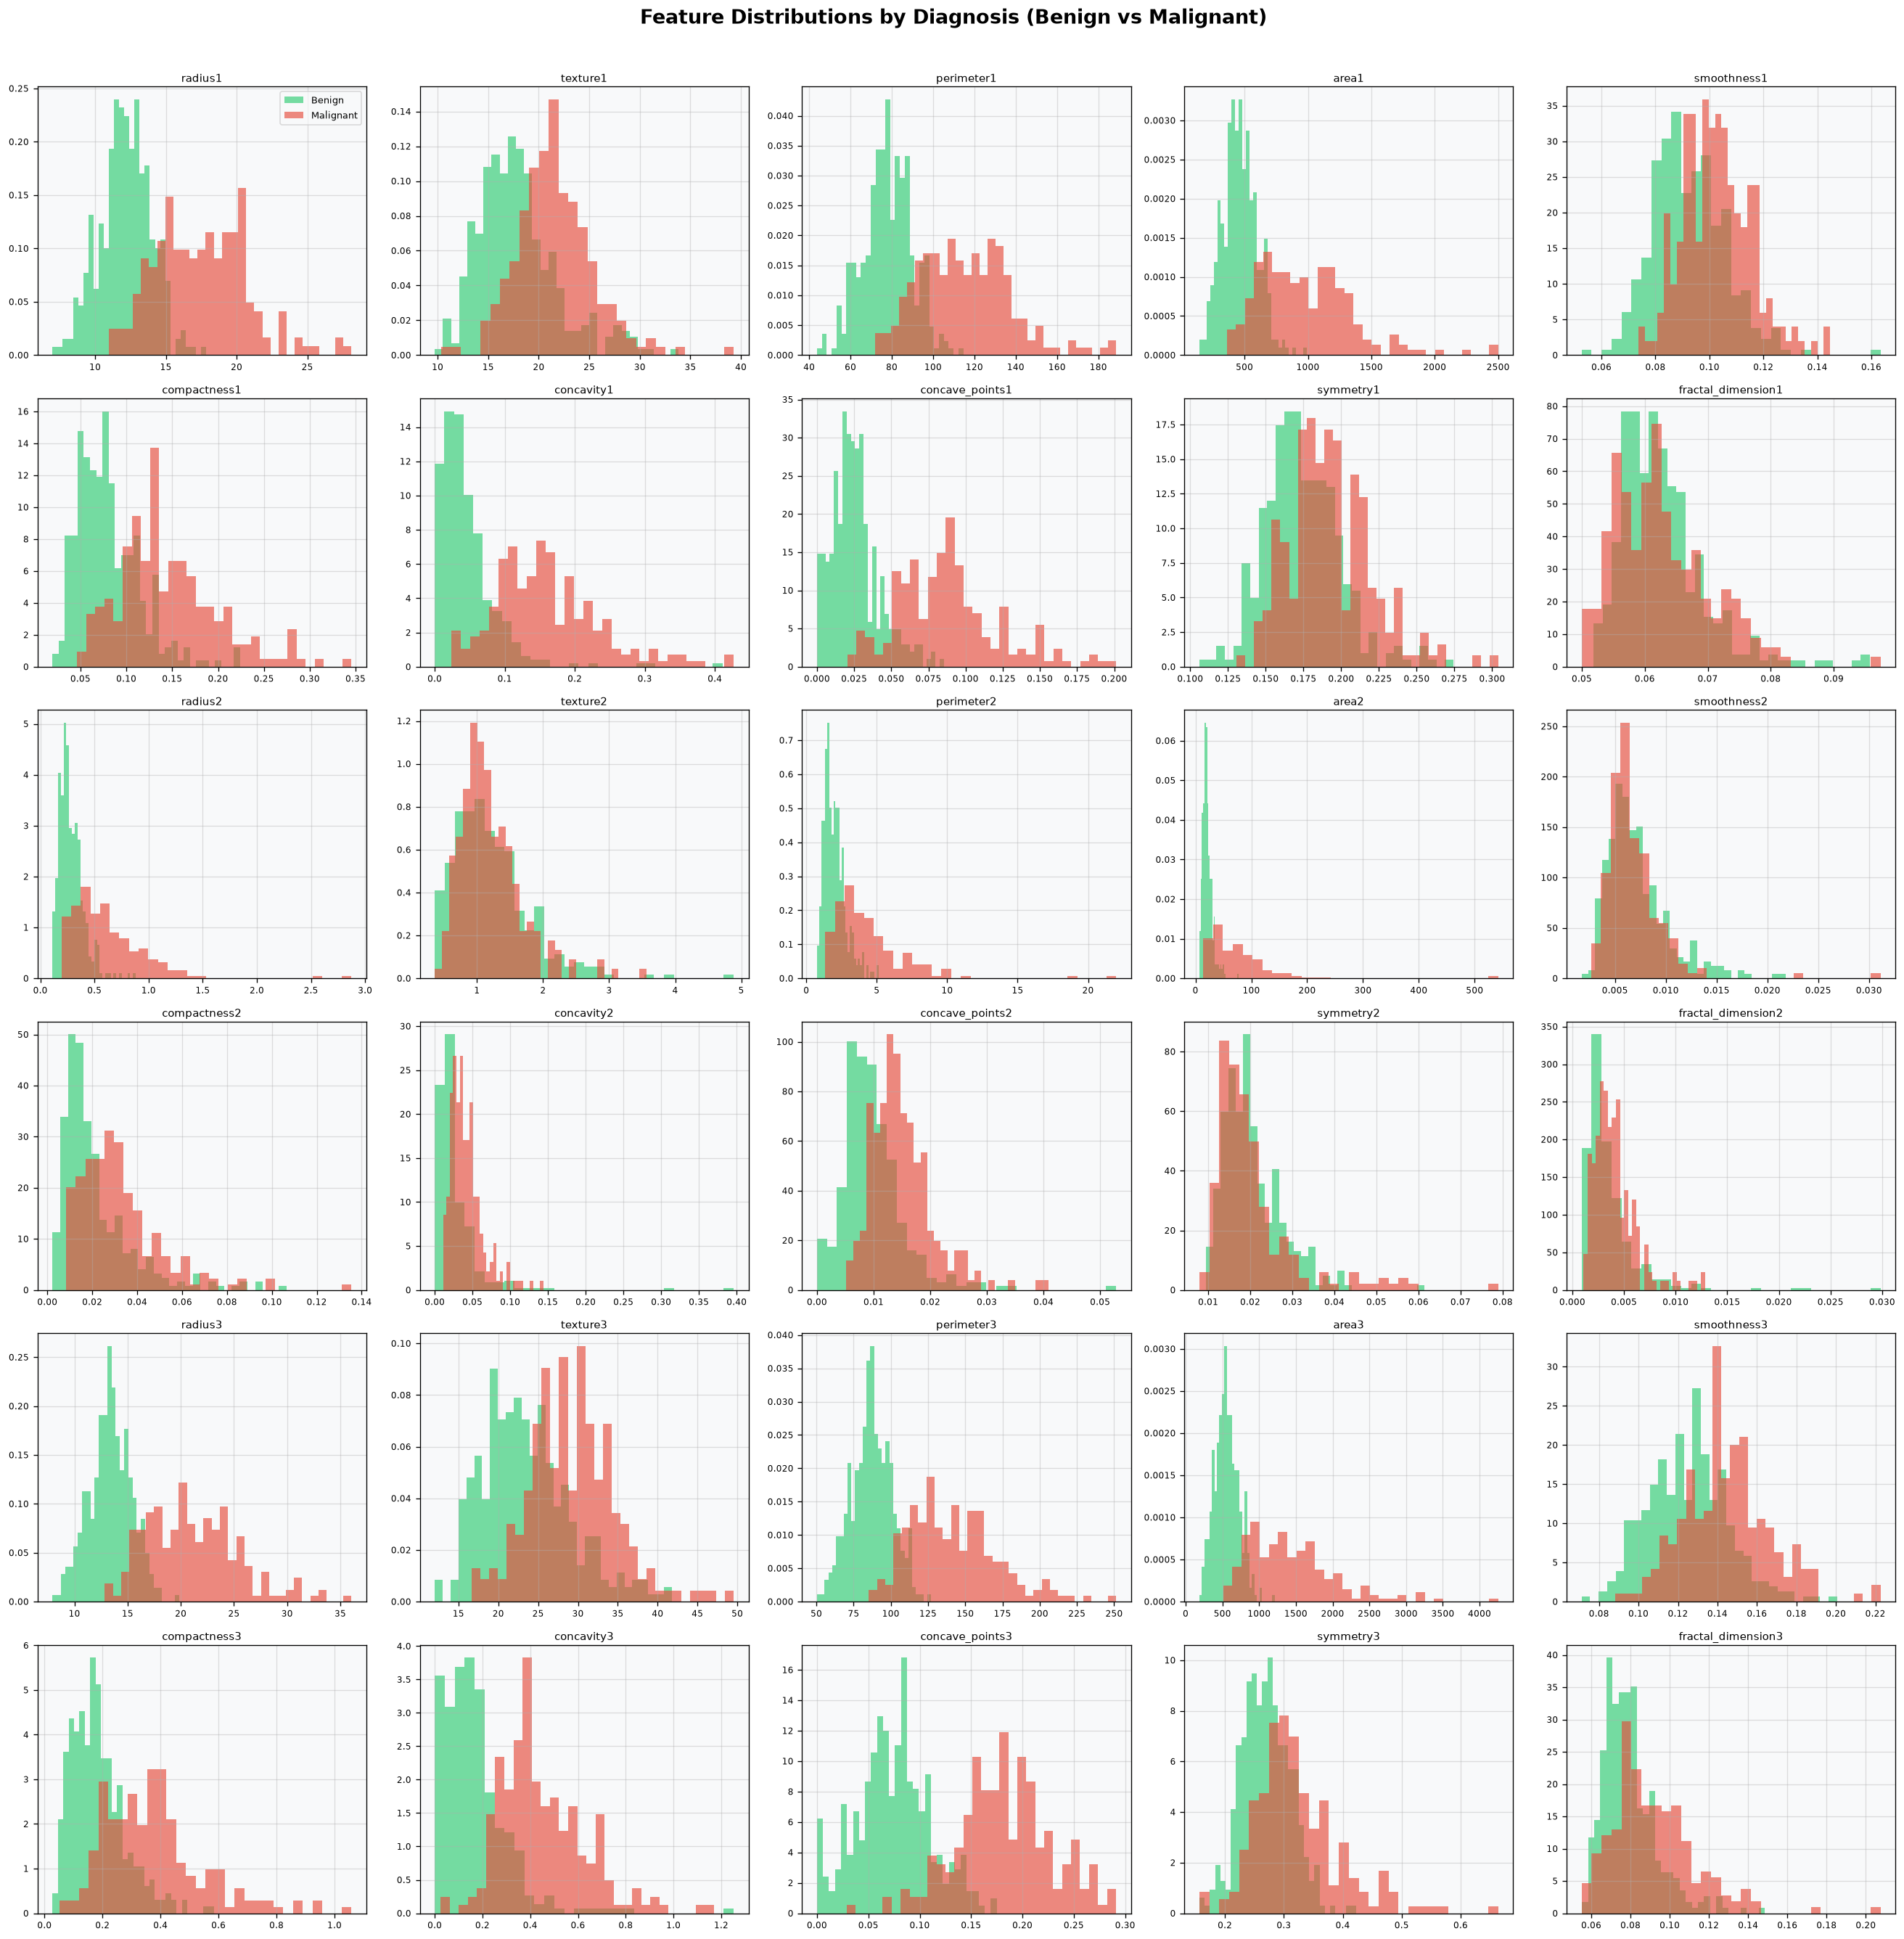

Figure saved: ..\..\results\figures\02_feature_distributions.png


In [12]:
df = X.copy()
df['Diagnosis'] = y['Diagnosis'].values

fig, axes = plt.subplots(6, 5, figsize=(22, 22))
fig.suptitle('Feature Distributions by Diagnosis (Benign vs Malignant)', fontsize=16, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes_flat[idx]
    for label, color in PALETTE.items():
        subset = df[df['Diagnosis'] == label][feature]
        ax.hist(subset, bins=30, alpha=0.65, color=color,
                label='Benign' if label == 'B' else 'Malignant',
                edgecolor='none', density=True)
    ax.set_title(feature, fontsize=9, pad=4)
    ax.tick_params(labelsize=7)
    if idx == 0:
        ax.legend(fontsize=8, framealpha=0.7)

for j in range(len(features), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '02_feature_distributions.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=130)
plt.show()
print(f'Figure saved: {fig_path}')

## 12. Correlation Heatmap

Pearson correlation matrix of all 30 features. High correlations are expected (mean/SE/worst share the same 10 base measurements).

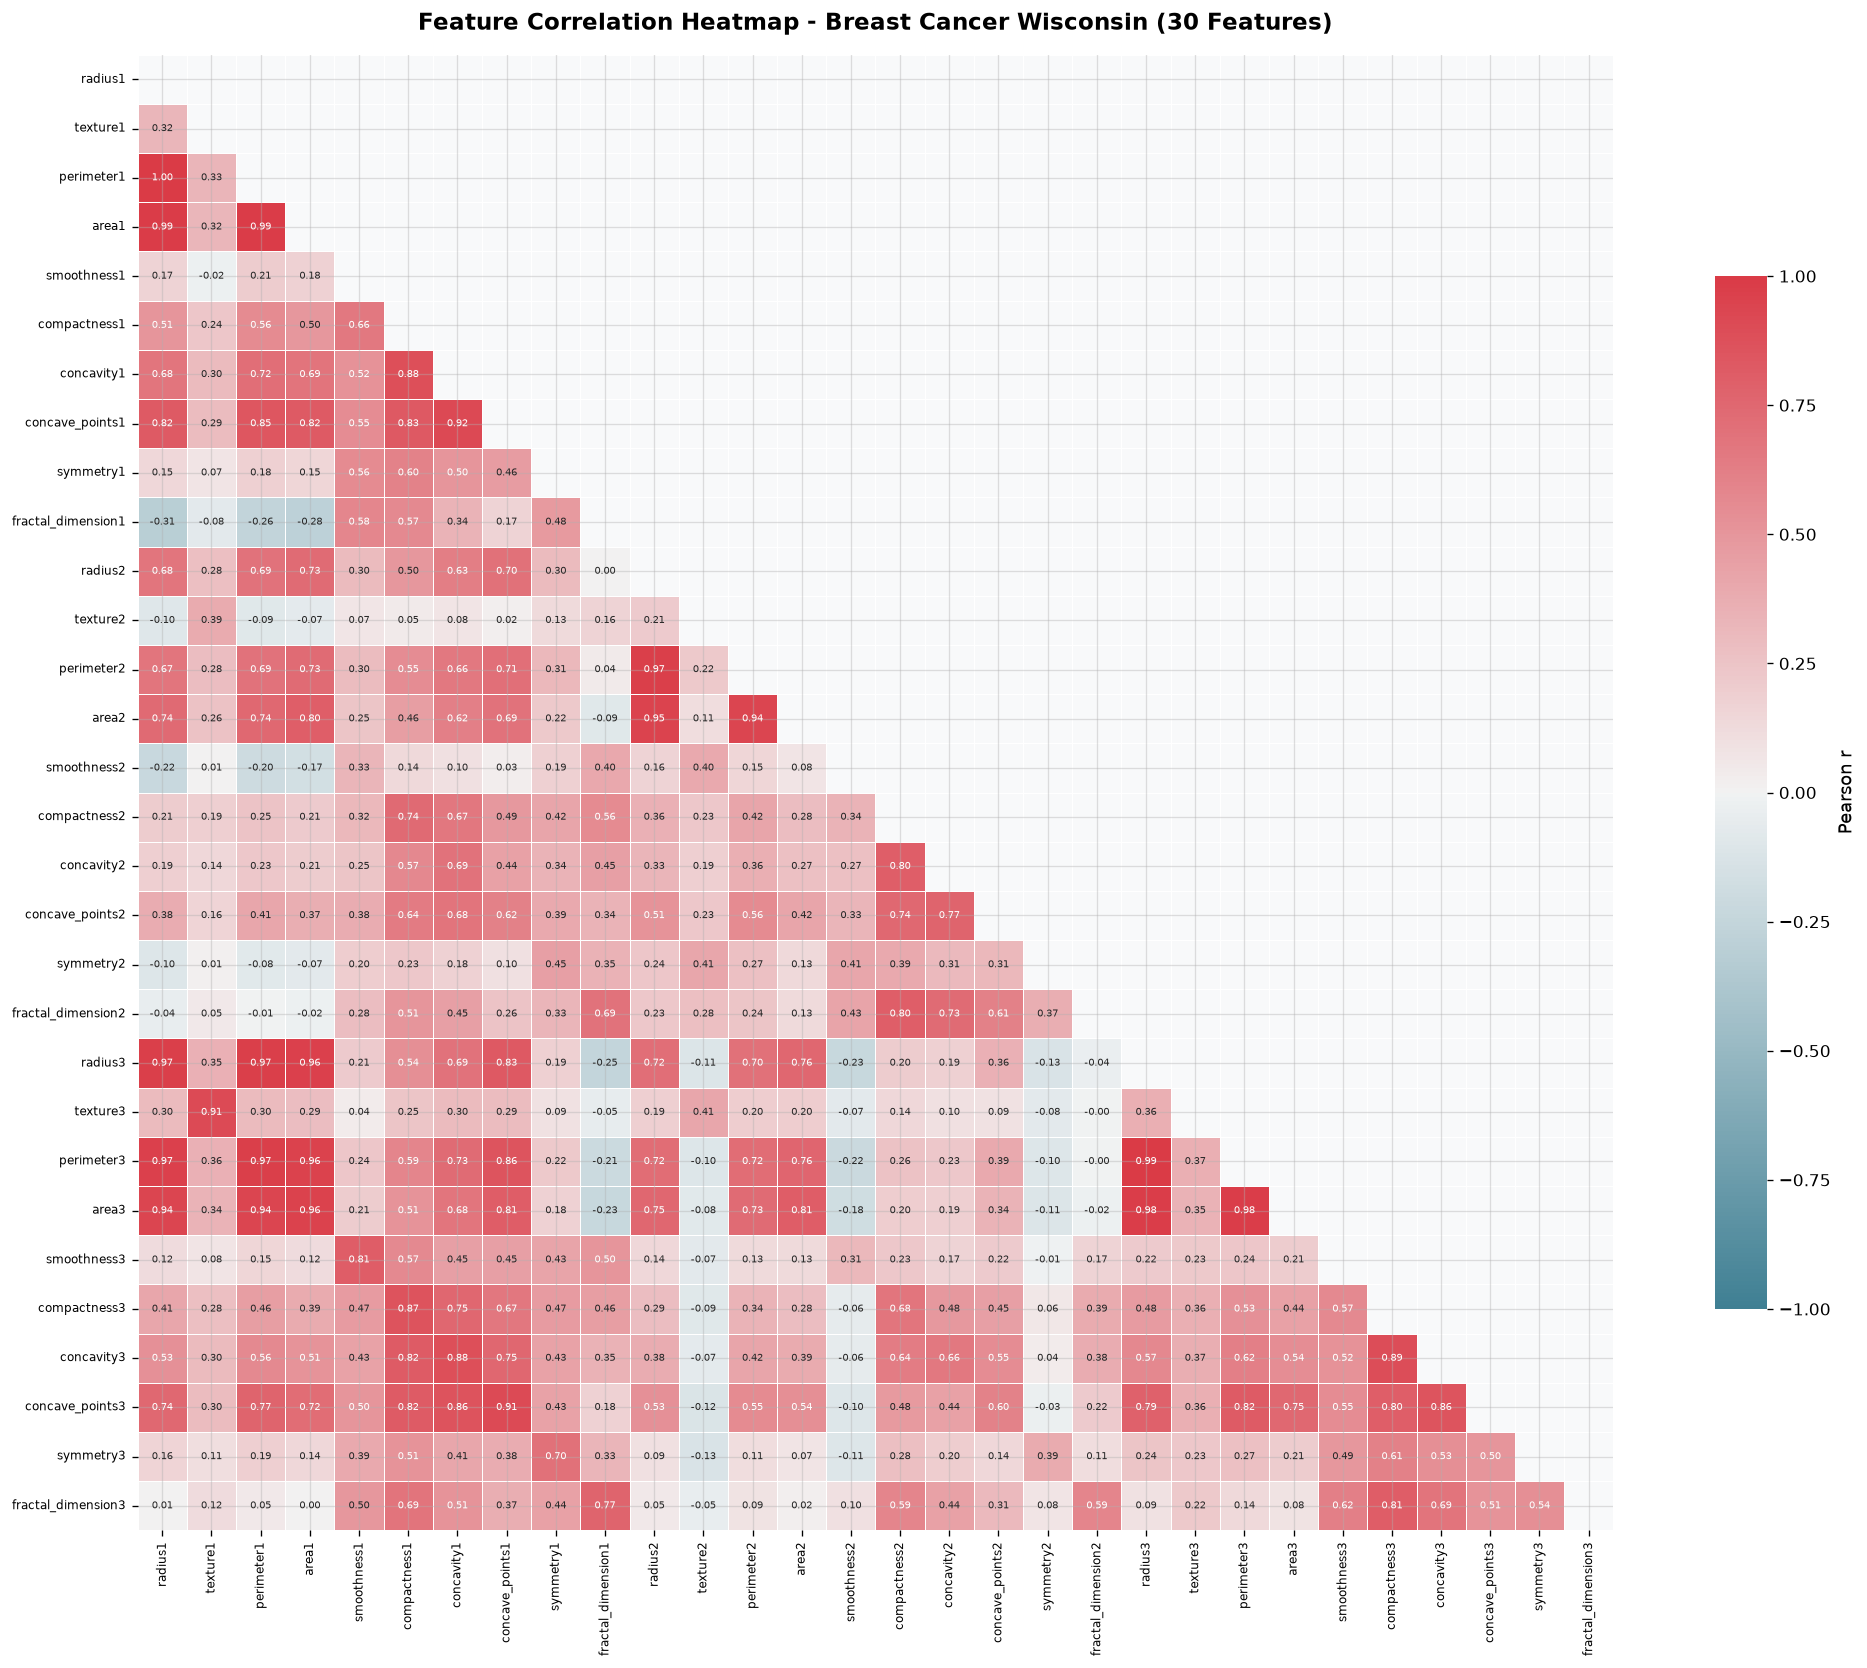

Figure saved: ..\..\results\figures\03_correlation_heatmap.png


In [13]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap,
    vmax=1.0, vmin=-1.0, center=0,
    annot=True, fmt='.2f',
    annot_kws={'size': 6},
    square=True, linewidths=0.3, linecolor='white',
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
    ax=ax
)
ax.set_title('Feature Correlation Heatmap - Breast Cancer Wisconsin (30 Features)',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(labelsize=7)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '03_correlation_heatmap.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=130)
plt.show()
print(f'Figure saved: {fig_path}')

## EDA Summary

| Property | Value |
|---|---|
| Dataset | Breast Cancer Wisconsin (Diagnostic) - UCI ID 17 |
| Samples | 569 |
| Features | 30 numerical (mean, SE, worst x 10 measurements) |
| Missing values | 0 |
| Duplicate rows | 0 |
| Benign (B) | 357 (62.7%) |
| Malignant (M) | 212 (37.3%) |

### Key Observations
1. **No data cleaning required** - dataset is complete and free of duplicates.
2. **Features span very different scales** - StandardScaler is mandatory before SOM training.
3. **High inter-feature correlations** visible in heatmap - expected (radius, perimeter, area are geometrically related).
4. **Class imbalance is mild** (62.7/37.3%) - acceptable for unsupervised clustering.
5. **Feature distributions differ** noticeably between classes - promising signal for SOM.

### Next Step: Phase 2
Implement preprocessing (StandardScaler) and train the Self-Organizing Map using MiniSom on X only.

---

# Phase 2 -- Preprocessing

Using ml/src/preprocessing.py -- clean, reusable functions that the SOM code will also call.

> **Core rule:** X (30 numerical features) goes into the SOM.
> y (diagnosis labels) stays completely separate and is used ONLY for post-hoc validation.

## Why StandardScaler?

The 30 features in this dataset span **very different numerical scales**:

| Feature | Typical range |
|---|---|
| rea_mean | 100 -- 2500 |
| ractal_dimension_mean | 0.04 -- 0.10 |
| 	exture_mean | 9 -- 40 |

**SOM uses Euclidean distance** to compare data points to neuron weights.
If features are unscaled, the large-magnitude ones (like rea) completely dominate the distance calculation -- the SOM would essentially ignore fractal dimension and smoothness.

**StandardScaler** transforms each feature to:
z = \frac{x - \mu}{\sigma}
Resulting in **zero mean and unit variance** per feature. Every feature contributes equally to distances, giving the SOM a fair view of all 30 dimensions.

> **Why not MinMaxScaler?**  
> Medical data has outliers (e.g., unusual tumour sizes). MinMaxScaler compresses the entire range to [0,1] which makes outliers distort the scale for all other samples. StandardScaler is more robust to outliers.

## P1. Import Preprocessing Module

In [14]:
import sys, os
from pathlib import Path

# Ensure project root (medical-som-clustering/) is on sys.path so that
# 'from ml.src import ...' works from within the notebook directory.
PROJECT_ROOT = str(Path('..', '..').resolve())   # ml/notebooks/ -> medical-som-clustering/
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from ml.src import preprocessing as prep
print('preprocessing imported from:', prep.__file__)
print('Available functions:', [f for f in dir(prep) if not f.startswith('_')])

preprocessing imported from: C:\Users\Harsh Seth\OneDrive\Documents\NN MEDICAL SOM\medical-som-clustering\ml\src\preprocessing.py
Available functions: ['FEATURE_NAMES', 'StandardScaler', 'get_preprocessing_summary', 'load_data', 'np', 'os', 'pd', 'prepare_features', 'scale_features', 'sys']


## P2. Load Data via preprocessing.load_data()

Uses the 3-tier loading strategy: ucimlrepo -> local CSV -> raw wdbc.data

In [15]:
# Paths relative to notebook location
LOCAL_CSV  = os.path.join('..', 'data', 'breast_cancer.csv')
WDBC_RAW   = os.path.join('..', '..', '..', 'wdbc.data')

X_raw, y_raw, load_source = prep.load_data(
    local_csv=LOCAL_CSV,
    wdbc_raw=WDBC_RAW
)

print(f'Load source : {load_source}')
print(f'X_raw shape : {X_raw.shape}')
print(f'y_raw shape : {y_raw.shape}')

Load source : ucimlrepo (online)
X_raw shape : (569, 30)
y_raw shape : (569, 1)


## P3. Separate Features and Labels

In [16]:
X, y_series, feature_names = prep.prepare_features(X_raw, y_raw)

print('=== Feature / Label Separation ===')
print(f'X shape          : {X.shape}   <- 30 features, used for SOM')
print(f'y shape          : {y_series.shape}   <- diagnosis labels, NOT used in SOM')
print(f'Feature count    : {len(feature_names)}')
print(f'"Diagnosis" in X : {"Diagnosis" in X.columns}   <- must be False')
print()
print('First 3 feature names :', feature_names[:3])
print('Last  3 feature names :', feature_names[-3:])
print()
print('y_series (first 5):')
print(y_series.head())

=== Feature / Label Separation ===
X shape          : (569, 30)   <- 30 features, used for SOM
y shape          : (569,)   <- diagnosis labels, NOT used in SOM
Feature count    : 30
"Diagnosis" in X : False   <- must be False

First 3 feature names : ['radius1', 'texture1', 'perimeter1']
Last  3 feature names : ['concave_points3', 'symmetry3', 'fractal_dimension3']

y_series (first 5):
0    M
1    M
2    M
3    M
4    M
Name: Diagnosis, dtype: str


## P4. All 30 Feature Names

In [17]:
print('All 30 feature names grouped by measurement type:\n')
groups = [
    ('Mean (features 1-10)',           feature_names[:10]),
    ('Standard Error (features 11-20)', feature_names[10:20]),
    ('Worst (features 21-30)',          feature_names[20:]),
]
for group_label, group_feats in groups:
    print(f'  [{group_label}]')
    for i, f in enumerate(group_feats, 1):
        print(f'    {i:2d}. {f}')
    print()

All 30 feature names grouped by measurement type:

  [Mean (features 1-10)]
     1. radius1
     2. texture1
     3. perimeter1
     4. area1
     5. smoothness1
     6. compactness1
     7. concavity1
     8. concave_points1
     9. symmetry1
    10. fractal_dimension1

  [Standard Error (features 11-20)]
     1. radius2
     2. texture2
     3. perimeter2
     4. area2
     5. smoothness2
     6. compactness2
     7. concavity2
     8. concave_points2
     9. symmetry2
    10. fractal_dimension2

  [Worst (features 21-30)]
     1. radius3
     2. texture3
     3. perimeter3
     4. area3
     5. smoothness3
     6. compactness3
     7. concavity3
     8. concave_points3
     9. symmetry3
    10. fractal_dimension3



## P5. Standardize Features with StandardScaler

In [18]:
from IPython.display import display
X_scaled, scaler = prep.scale_features(X)

print('=== Scaling Results ===')
print(f'X_scaled shape  : {X_scaled.shape}')
print(f'X_scaled dtype  : {X_scaled.dtype}')
print(f'Column means~0  : {np.allclose(X_scaled.mean(axis=0), 0, atol=1e-6)}')
print(f'Column stds~1   : {np.allclose(X_scaled.std(axis=0),  1, atol=1e-6)}')
print()
print('Sample scaled values (first 3 rows, first 5 features):')
import pandas as pd
sample = pd.DataFrame(X_scaled[:3, :5], columns=feature_names[:5])
display(sample.round(4))

=== Scaling Results ===
X_scaled shape  : (569, 30)
X_scaled dtype  : float64
Column means~0  : True
Column stds~1   : True

Sample scaled values (first 3 rows, first 5 features):


,radius1,texture1,perimeter1,area1,smoothness1
0,1.0971,-2.0733,1.2699,0.9844,1.5685
1,1.8298,-0.3536,1.6860,1.9087,-0.8270
2,1.5799,0.4562,1.5665,1.5589,0.9422


## P6. Before vs After Scaling Comparison

In [19]:
from IPython.display import display
compare = pd.DataFrame({
    'feature'         : feature_names,
    'original_mean'   : X.mean().to_numpy().round(4),
    'original_std'    : X.std().to_numpy().round(4),
    'scaled_mean'     : X_scaled.mean(axis=0).round(6),
    'scaled_std'      : X_scaled.std(axis=0).round(6),
})
print('Before vs After Scaling (first 10 features):')
display(compare.head(10))

Before vs After Scaling (first 10 features):


,feature,original_mean,original_std,scaled_mean,scaled_std
0,radius1,14.1273,3.5240,-0.0,1.0
1,texture1,19.2896,4.3010,0.0,1.0
2,perimeter1,91.9690,24.2990,-0.0,1.0
3,area1,654.8891,351.9141,-0.0,1.0
4,smoothness1,0.0964,0.0141,-0.0,1.0
5,compactness1,0.1043,0.0528,0.0,1.0
6,concavity1,0.0888,0.0797,0.0,1.0
7,concave_points1,0.0489,0.0388,-0.0,1.0
8,symmetry1,0.1812,0.0274,0.0,1.0
9,fractal_dimension1,0.0628,0.0071,0.0,1.0


## P7. Preprocessing Summary

In [20]:
summary = prep.get_preprocessing_summary(X, y_series, X_scaled, feature_names)

print('=== Preprocessing Summary ===')
for k, v in summary.items():
    print(f'  {k:<25s}: {v}')

print()
print('CHECKS:')
print(f'  Diagnosis label in X     : {summary["y_in_X"]}   <- MUST be False')
print(f'  Scaled means near 0      : {summary["scaled_means_near_0"]}  <- MUST be True')
print(f'  Scaled stds near 1       : {summary["scaled_stds_near_1"]}  <- MUST be True')
print(f'  Missing values in X      : {summary["missing_in_X"]}       <- MUST be 0')
print()
print('What goes into the SOM   : X_scaled  (shape', X_scaled.shape, ')')
print('What NEVER goes into SOM : y_series  (shape', y_series.shape, ')')

=== Preprocessing Summary ===
  n_samples                : 569
  n_features               : 30
  feature_names            : ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']
  X_dtype                  : [dtype('float64')]
  X_scaled_dtype           : float64
  missing_in_X             : 0
  class_distribution       : {'B': 357, 'M': 212}
  scaled_means_near_0      : True
  scaled_stds_near_1       : True
  y_in_X                   : False

CHECKS:
  Diagnosis label in X     : False   <- MUST be False
  Scaled means near 0      : True  <- MUST be True
  Scaled stds near 1       : True  <- MUST be True
  Miss

## Preprocessing Stage Complete

| Object | Description | Shape | SOM input? |
|---|---|---|---|
| X | Raw feature DataFrame | (569, 30) | No |
| X_scaled | Standardized numpy array | (569, 30) | **YES** |
| y_series | Diagnosis labels (M/B) | (569,) | **Never** |
| scaler | Fitted StandardScaler | -- | Reuse for inverse_transform |

### Next Step: Phase 3
Train the Self-Organizing Map on X_scaled only using **MiniSom(11, 11, 30)**.

---

# Phase 3 -- SOM Training

Using `ml/src/som_model.py` -- MiniSom-based Self-Organizing Map.

> **Input:**  `X_scaled`  (569 x 30, standardized features only)
> **Labels:** `y_series` is NEVER passed to the SOM. Used only post-hoc for validation.

## How a Self-Organizing Map Trains

A SOM is an **unsupervised neural network** that maps high-dimensional input to a low-dimensional (here: 2D) grid of neurons while preserving the topological structure of the data.

### Training Algorithm (one iteration)
1. **Initialize** -- neuron weight vectors are set to random samples drawn from X_scaled.
2. **Select a sample** -- pick a random training sample `x` from X_scaled.
3. **Find the BMU** -- the neuron whose weight vector is closest to `x` in Euclidean distance.
4. **Update weights** -- move the BMU *and its neighbours* towards `x`; learning rate and neighbourhood radius both decay over time.
5. **Repeat** for N_ITERS steps.

After training, similar data points map to the same or adjacent neurons -- the SOM has **learned the structure of the data** without ever seeing the diagnosis labels.

## Hyperparameters

| Parameter | Value | Reasoning |
|---|---|---|
| Grid size | 11 x 11 (121 neurons) | Rule of thumb: 5*sqrt(N) = ~119 for N=569 |
| Sigma (initial) | 1.5 | Initial neighbourhood radius; shrinks during training |
| Learning rate | 0.5 | Aggressive early, decays to near-zero by end |
| Iterations | 10,000 | ~17.5 passes over 569 samples; sufficient for convergence |
| Random seed | 42 | For reproducibility |
| Topology | rectangular | Standard 2D grid |


## S1. Import SOM Module

In [21]:
import sys, os, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = str(Path('..', '..').resolve())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from ml.src import som_model as sm
FIGURES_DIR = os.path.join('..', '..', 'results', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print('som_model imported from:', sm.__file__)
print('Default grid :', sm.DEFAULT_GRID)
print('Default iters:', sm.DEFAULT_ITERS)

som_model imported from: C:\Users\Harsh Seth\OneDrive\Documents\NN MEDICAL SOM\medical-som-clustering\ml\src\som_model.py
Default grid : (11, 11)
Default iters: 10000


## S2. Create SOM

Grid: **11 x 11** = 121 neurons, each with a weight vector of length 30.

In [22]:
N_ROWS  = 11
N_COLS  = 11
SIGMA   = sm.DEFAULT_SIGMA
LR      = sm.DEFAULT_LR
N_ITERS = sm.DEFAULT_ITERS
SEED    = sm.DEFAULT_SEED

som = sm.create_som(
    n_rows        = N_ROWS,
    n_cols        = N_COLS,
    n_features    = X_scaled.shape[1],
    sigma         = SIGMA,
    learning_rate = LR,
    random_seed   = SEED,
)

print('SOM created (untrained):')
print(f'  Grid          : {N_ROWS} x {N_COLS} = {N_ROWS*N_COLS} neurons')
print(f'  Input dim     : {X_scaled.shape[1]} features')
print(f'  Codebook shape: {som.get_weights().shape}   (rows, cols, features)')
print(f'  Sigma         : {SIGMA}')
print(f'  Learning rate : {LR}')
print(f'  Iterations    : {N_ITERS}')
print(f'  Seed          : {SEED}')
print()
print('Diagnosis labels in SOM input? NO -- X_scaled contains features only.')

SOM created (untrained):
  Grid          : 11 x 11 = 121 neurons
  Input dim     : 30 features
  Codebook shape: (11, 11, 30)   (rows, cols, features)
  Sigma         : 1.5
  Learning rate : 0.5
  Iterations    : 10000
  Seed          : 42

Diagnosis labels in SOM input? NO -- X_scaled contains features only.


## S3. Train SOM

Training on `X_scaled` (569 x 30). **y_series is not used here.**

In [23]:
som, qe_history = sm.train_som(
    som,
    X_scaled,
    n_iterations    = N_ITERS,
    random_seed     = SEED,
    record_qe_every = 1000,
)
print()
print('QE checkpoints during training:')
for step, qe in qe_history:
    print(f'  step {step:6d}  QE = {qe:.5f}')

Training SOM 11x11 for 10000 iterations ...
  step   1000/10000  |  QE = 2.75993
  step   2000/10000  |  QE = 2.68741
  step   3000/10000  |  QE = 2.58842
  step   4000/10000  |  QE = 2.53492
  step   5000/10000  |  QE = 2.46020
  step   6000/10000  |  QE = 2.38374


  step   7000/10000  |  QE = 2.30969


  step   8000/10000  |  QE = 2.26394


  step   9000/10000  |  QE = 2.19723
  step  10000/10000  |  QE = 2.13040
Training complete.

QE checkpoints during training:
  step      0  QE = 2.29107
  step   1000  QE = 2.75993
  step   2000  QE = 2.68741
  step   3000  QE = 2.58842
  step   4000  QE = 2.53492
  step   5000  QE = 2.46020
  step   6000  QE = 2.38374
  step   7000  QE = 2.30969
  step   8000  QE = 2.26394
  step   9000  QE = 2.19723
  step  10000  QE = 2.13040


## S4. Quantization Error & Topographic Error

In [24]:
qe = sm.get_quantization_error(som, X_scaled)
te = sm.get_topographic_error(som, X_scaled)

print('=== SOM Quality Metrics ===')
print(f'  Quantization Error (QE) : {qe:.6f}')
print(f'  Topographic Error  (TE) : {te:.6f}')
print()
print('Interpretation:')
print('  QE = mean distance from each sample to its BMU neuron weight.')
print('       Lower = SOM represents data more faithfully.')
print('  TE = fraction of samples whose 2nd-BMU is not adjacent to their BMU.')
print('       Lower = better topology preservation. TE=0 is perfect.')

=== SOM Quality Metrics ===
  Quantization Error (QE) : 2.130398
  Topographic Error  (TE) : 0.159930

Interpretation:
  QE = mean distance from each sample to its BMU neuron weight.
       Lower = SOM represents data more faithfully.
  TE = fraction of samples whose 2nd-BMU is not adjacent to their BMU.
       Lower = better topology preservation. TE=0 is perfect.


## S5. BMU Assignments

In [25]:
bmu_indices = sm.get_bmu_indices(som, X_scaled)

print(f'BMU shape: {bmu_indices.shape}  (one (row,col) per sample)')
print()
print('First 10 BMU assignments:')
for i, (r, c) in enumerate(bmu_indices[:10]):
    print(f'  Sample {i:3d}  ->  neuron ({r:2d}, {c:2d})')

n_unique = len(set(map(tuple, bmu_indices)))
print(f'\nUnique neurons activated: {n_unique} / {N_ROWS*N_COLS}')

BMU shape: (569, 2)  (one (row,col) per sample)

First 10 BMU assignments:
  Sample   0  ->  neuron (10,  7)
  Sample   1  ->  neuron ( 6,  7)
  Sample   2  ->  neuron ( 8,  8)
  Sample   3  ->  neuron (10,  2)
  Sample   4  ->  neuron ( 7,  8)
  Sample   5  ->  neuron ( 9,  3)
  Sample   6  ->  neuron ( 6,  6)
  Sample   7  ->  neuron ( 8,  2)
  Sample   8  ->  neuron ( 9,  4)
  Sample   9  ->  neuron (10,  3)

Unique neurons activated: 121 / 121


## S6. U-Matrix

Each cell = mean Euclidean distance from that neuron to its direct neighbours.

- **Dark regions** (high distance) = cluster boundaries
- **Light regions** (low distance) = cluster cores / dense data areas

U-Matrix saved: ..\..\results\figures\04_umatrix_11x11.png


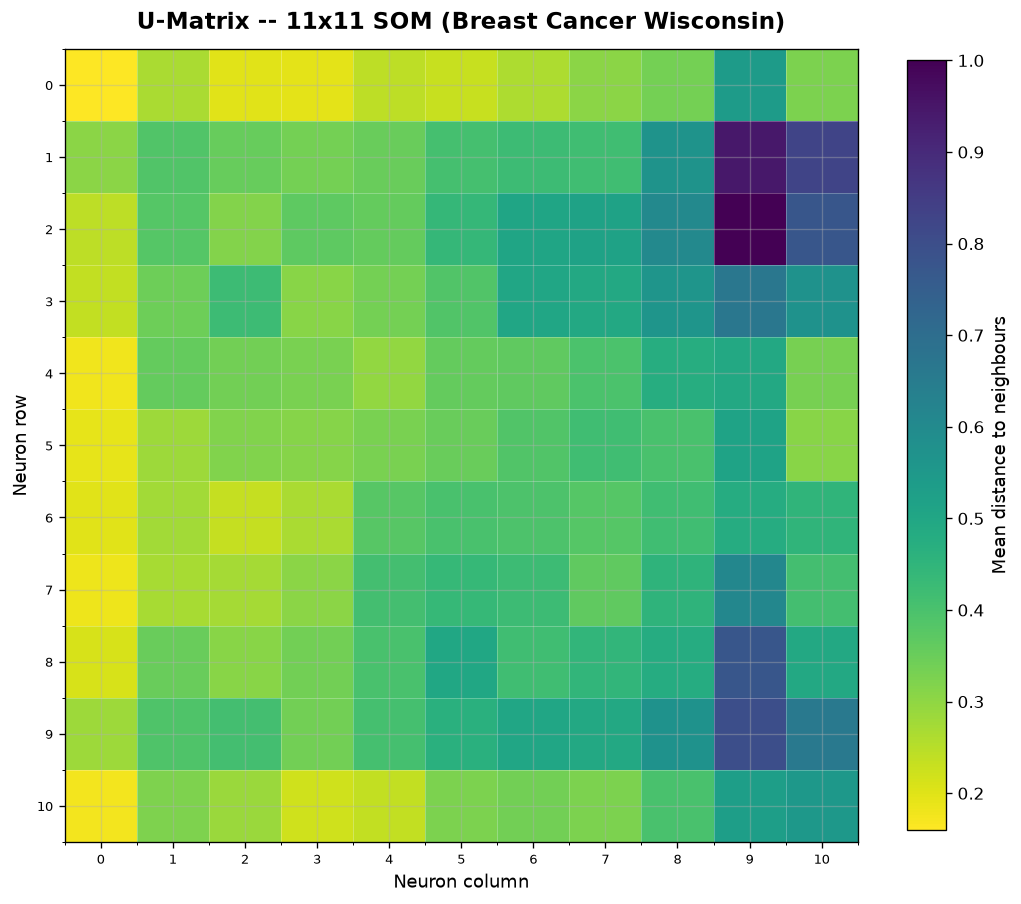

U-Matrix plotted and saved.


In [26]:
fig = sm.plot_umatrix(
    som,
    save_path=os.path.join(FIGURES_DIR, '04_umatrix_11x11.png'),
    title='U-Matrix -- 11x11 SOM (Breast Cancer Wisconsin)'
)
plt.show()
print('U-Matrix plotted and saved.')

## S7. Hit Map

How many training samples each neuron won (was the BMU for).

- **High count** = densely populated region of data space
- **Zero** = dead neuron (not activated by any sample)

Hit map saved: ..\..\results\figures\05_hitmap_11x11.png


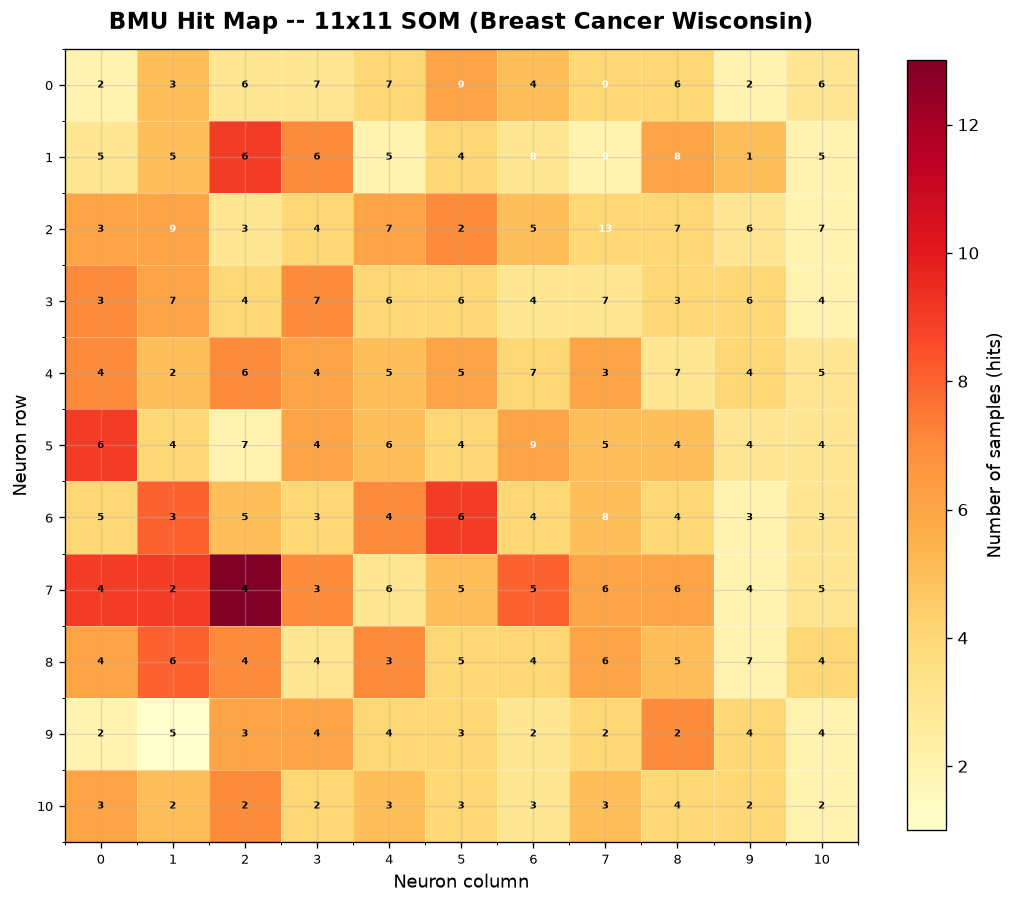

Hit map plotted and saved.


In [27]:
fig = sm.plot_hit_map(
    som,
    X_scaled,
    save_path=os.path.join(FIGURES_DIR, '05_hitmap_11x11.png'),
    title='BMU Hit Map -- 11x11 SOM (Breast Cancer Wisconsin)'
)
plt.show()
print('Hit map plotted and saved.')

## S8. Training Curve (QE vs Iterations)

A clear downward trend confirms the SOM is converging.

Training curve saved: ..\..\results\figures\06_training_curve_11x11.png


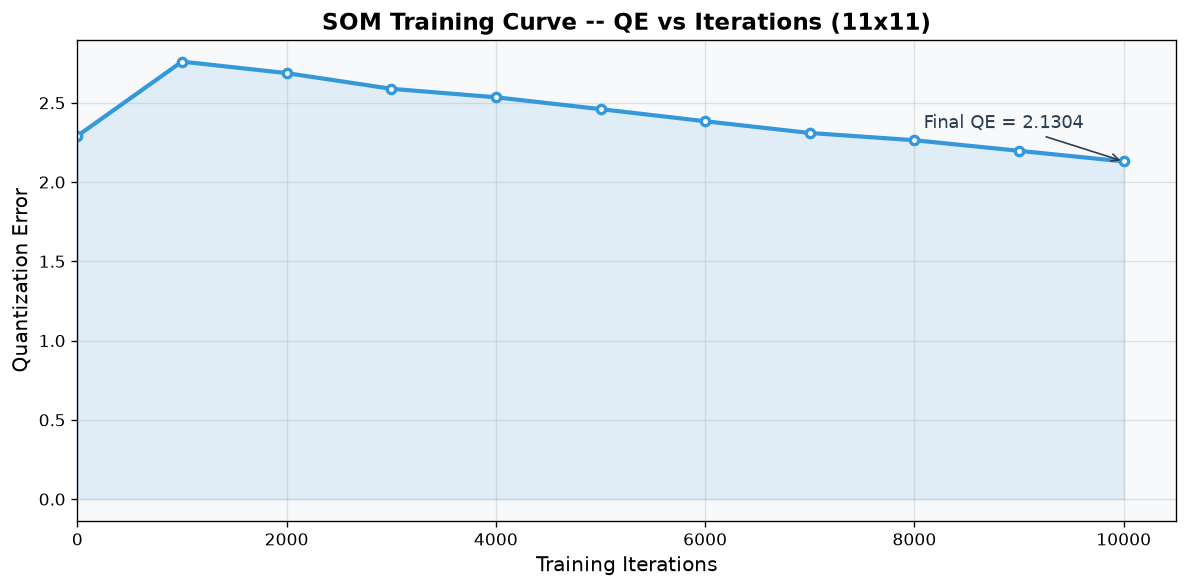

Training curve plotted and saved.


In [28]:
fig = sm.plot_training_curve(
    qe_history,
    save_path=os.path.join(FIGURES_DIR, '06_training_curve_11x11.png'),
    title='SOM Training Curve -- QE vs Iterations (11x11)'
)
plt.show()
print('Training curve plotted and saved.')

## S9. Full SOM Summary

In [29]:
summary = sm.get_som_summary(
    som, X_scaled, N_ITERS, SIGMA, LR, SEED
)

print('=== SOM Training Summary ===')
print(f'{"Parameter":<28} {"Value"}')
print('-' * 50)
for k, v in summary.items():
    print(f'  {k:<26} {v}')

codebook = sm.get_codebook(som)
print()
print(f'Codebook shape : {codebook.shape}')
print(f'Flat codebook  : {codebook.reshape(-1, 30).shape}  -> input for K-Means (Phase 4)')

=== SOM Training Summary ===
Parameter                    Value
--------------------------------------------------
  grid_size                  11x11
  n_neurons                  121
  n_features                 30
  n_training_samples         569
  n_iterations               10000
  sigma                      1.5
  learning_rate              0.5
  random_seed                42
  quantization_error         2.130398
  topographic_error          0.15993
  dead_neurons               0
  max_hits_per_neuron        13
  unique_bmus                121

Codebook shape : (11, 11, 30)
Flat codebook  : (121, 30)  -> input for K-Means (Phase 4)


## SOM Training Stage Complete

| Output | Shape | Next use |
|---|---|---|
| `som` | trained MiniSom | K-Means on codebook |
| `qe_history` | list of (step, QE) | Already plotted |
| `bmu_indices` | (569, 2) | Map samples to clusters |
| `codebook` | (11, 11, 30) | Reshape to (121, 30) for K-Means |

### Next Step: Phase 4 -- Cluster Extraction
Run K-Means on the flattened codebook vectors `(121, 30)` to assign cluster IDs to neurons, then map each sample to its cluster via its BMU. Only THEN bring `y_series` back to evaluate how well the clusters align with diagnosis labels.

---

# Phase 4 -- Cluster Extraction (K-Means on SOM Codebook)

Using `ml/src/clustering.py`.

### Correct Pipeline
```
X_scaled (569 x 30)
    -> SOM training                [Phase 3 -- done]
    -> Codebook vectors (121 x 30) [this phase]
    -> K-Means on codebook         [this phase]
    -> Cluster ID per neuron
    -> BMU of each sample -> cluster assignment
    -> POST-HOC: bring y_series back for validation only
```

> **Critical:** K-Means runs on 121 neuron vectors, NOT on the 569 raw patient samples.
> Diagnosis labels (`y_series`) are brought back ONLY after cluster assignment is complete.

## C1. Import Clustering Module

In [30]:
import sys, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = str(Path('..', '..').resolve())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from ml.src import clustering as cl
FIGURES_DIR = os.path.join('..', '..', 'results', 'figures')

print('clustering imported from:', cl.__file__)
print('Functions available:', [f for f in dir(cl) if not f.startswith('_')])

clustering imported from: C:\Users\Harsh Seth\OneDrive\Documents\NN MEDICAL SOM\medical-som-clustering\ml\src\clustering.py
Functions available: ['CLUSTER_COLORS', 'KMeans', 'ListedColormap', 'assign_neuron_clusters', 'assign_sample_clusters', 'cluster_diagnosis_distribution', 'cluster_feature_profiles', 'cluster_sizes', 'extract_codebook_flat', 'get_clustering_summary', 'mpatches', 'np', 'os', 'pd', 'plot_cluster_feature_heatmap', 'plot_cluster_sizes', 'plot_diagnosis_per_cluster', 'plot_som_cluster_map', 'plt', 'run_kmeans', 'select_k_elbow', 'silhouette_score']


## C2. Extract Codebook Vectors

Flatten the SOM weight tensor from **(11, 11, 30)** to **(121, 30)**.
These 121 vectors represent the neuron weight positions in 30-dimensional feature space.

In [31]:
from IPython.display import display
codebook_flat, n_rows, n_cols = cl.extract_codebook_flat(som)

print(f'SOM weights shape (raw)   : {som.get_weights().shape}')
print(f'Codebook flat shape       : {codebook_flat.shape}  <- K-Means input')
print(f'Grid dimensions           : {n_rows} x {n_cols}')
print()
print('First 3 neuron vectors (first 5 features):')
df_cb = pd.DataFrame(codebook_flat[:3, :5], columns=feature_names[:5])
display(df_cb.round(4))
print()
print('NOTE: K-Means will run on these 121 vectors -- NOT on 569 patient samples.')

SOM weights shape (raw)   : (11, 11, 30)
Codebook flat shape       : (121, 30)  <- K-Means input
Grid dimensions           : 11 x 11

First 3 neuron vectors (first 5 features):


,radius1,texture1,perimeter1,area1,smoothness1
0,-1.3432,-0.4506,-1.3224,-1.0964,1.0014
1,-1.2804,-0.6778,-1.2617,-1.0567,0.2197
2,-1.1612,-0.6451,-1.1596,-0.9711,-0.5655



NOTE: K-Means will run on these 121 vectors -- NOT on 569 patient samples.


## C3. Select K -- Elbow Method

We test K = 2 through 8 on the codebook vectors and pick the **elbow point** in the Within-Cluster Sum of Squares (WCSS) curve.

**Why not just K=2?**  
Although there are 2 diagnosis classes, clustering is unsupervised. The SOM may reveal finer structure (e.g. a borderline group, or sub-types within malignant). We let the data speak first, then validate against labels afterwards.

**Why elbow?**  
Simple, defensible, and appropriate for a codebook of only 121 vectors. The elbow is where adding another cluster gives diminishing returns in WCSS reduction.

In [32]:
print('Elbow analysis on SOM codebook vectors (K=2..8):')
print('-' * 55)
wcss_results, sil_results, best_k = cl.select_k_elbow(
    codebook_flat, k_range=range(2, 9), seed=42
)
print('-' * 55)
print(f'Elbow point -> selected K = {best_k}')

Elbow analysis on SOM codebook vectors (K=2..8):
-------------------------------------------------------


  K= 2  WCSS= 1979.501  Silhouette=0.3877


  K= 3  WCSS= 1536.726  Silhouette=0.3687


  K= 4  WCSS= 1315.264  Silhouette=0.3208

  K= 5  WCSS= 1155.359  Silhouette=0.3388


  K= 6  WCSS= 1015.894  Silhouette=0.2275


  K= 7  WCSS=  942.070  Silhouette=0.2075


  K= 8  WCSS=  847.334  Silhouette=0.2186
-------------------------------------------------------
Elbow point -> selected K = 3


## C4. Elbow & Silhouette Plot

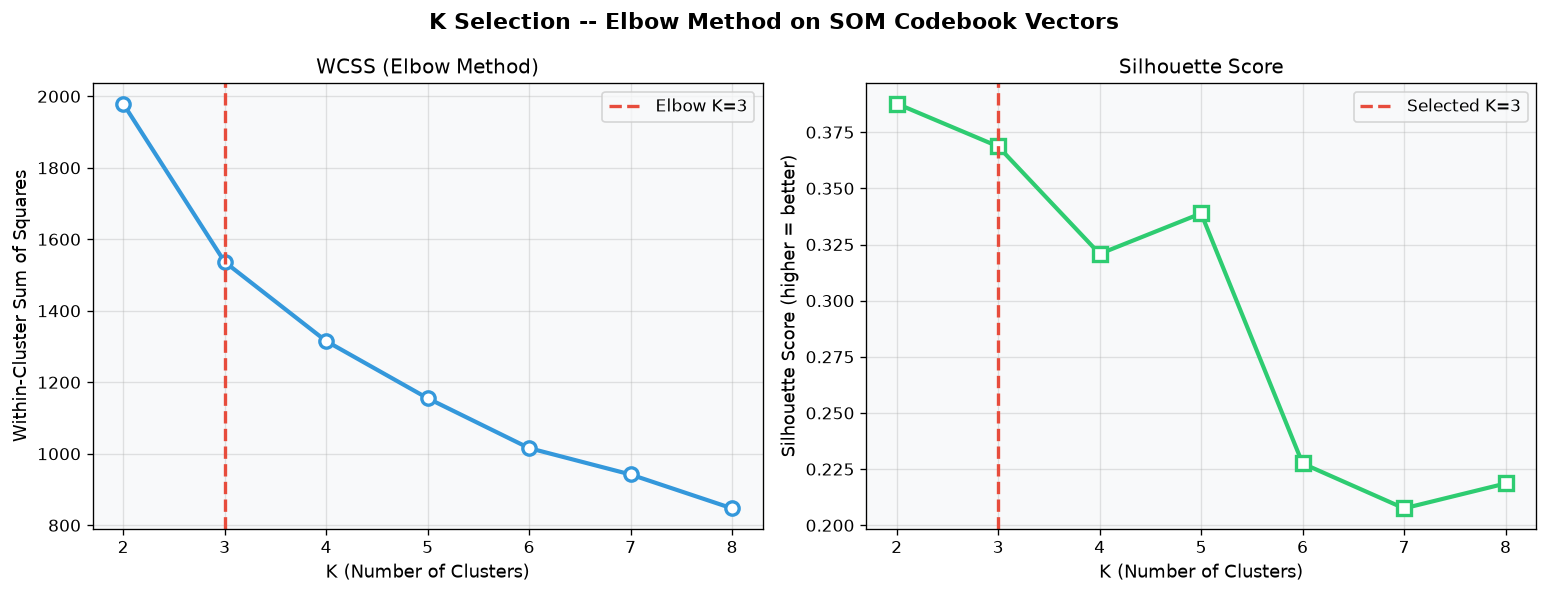

Figure saved: ..\..\results\figures\07_elbow_silhouette.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('K Selection -- Elbow Method on SOM Codebook Vectors',
             fontsize=13, fontweight='bold')

ks    = [r[0] for r in wcss_results]
wcss  = [r[1] for r in wcss_results]
sils  = [r[1] for r in sil_results]

# WCSS
ax1 = axes[0]
ax1.plot(ks, wcss, 'o-', color='#3498db', linewidth=2.5, markersize=8,
         markerfacecolor='white', markeredgewidth=2)
ax1.axvline(x=best_k, color='#e74c3c', linestyle='--',
            linewidth=2, label=f'Elbow K={best_k}')
ax1.set_title('WCSS (Elbow Method)', fontsize=12)
ax1.set_xlabel('K (Number of Clusters)')
ax1.set_ylabel('Within-Cluster Sum of Squares')
ax1.set_xticks(ks)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.35)

# Silhouette
ax2 = axes[1]
ax2.plot(ks, sils, 's-', color='#2ecc71', linewidth=2.5, markersize=8,
         markerfacecolor='white', markeredgewidth=2)
ax2.axvline(x=best_k, color='#e74c3c', linestyle='--',
            linewidth=2, label=f'Selected K={best_k}')
ax2.set_title('Silhouette Score', fontsize=12)
ax2.set_xlabel('K (Number of Clusters)')
ax2.set_ylabel('Silhouette Score (higher = better)')
ax2.set_xticks(ks)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.35)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '07_elbow_silhouette.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Figure saved: {fig_path}')

## C5. Run K-Means on Codebook

K-Means is fitted on the **121 neuron vectors** (not the 569 patient samples).

In [34]:
K = best_k

kmeans, neuron_labels = cl.run_kmeans(codebook_flat, k=K, seed=42)

print(f'K-Means fitted:')
print(f'  K selected         : {K}')
print(f'  Input shape        : {codebook_flat.shape}  (121 neuron vectors x 30 features)')
print(f'  neuron_labels shape: {neuron_labels.shape}  (cluster ID for each neuron)')
print(f'  Unique clusters    : {np.unique(neuron_labels)}')
print()
print('Cluster ID count for neurons:')
for cid in range(K):
    n_neurons = (neuron_labels == cid).sum()
    print(f'  Cluster {cid}: {n_neurons} neurons')

K-Means fitted:
  K selected         : 3
  Input shape        : (121, 30)  (121 neuron vectors x 30 features)
  neuron_labels shape: (121,)  (cluster ID for each neuron)
  Unique clusters    : [0 1 2]

Cluster ID count for neurons:
  Cluster 0: 70 neurons
  Cluster 1: 27 neurons
  Cluster 2: 24 neurons


## C6. Assign Clusters to Neurons and Samples

In [35]:
# Reshape neuron labels back to 11x11 grid
cluster_grid = cl.assign_neuron_clusters(n_rows, n_cols, neuron_labels)
print(f'Cluster grid shape: {cluster_grid.shape}')
print('Cluster grid (rows=SOM rows, cols=SOM cols):')
print(cluster_grid)
print()

# Map each sample's BMU -> cluster
sample_clusters = cl.assign_sample_clusters(bmu_indices, cluster_grid)
print(f'Sample cluster assignments shape: {sample_clusters.shape}')
print(f'First 10 sample -> cluster: {sample_clusters[:10]}')

Cluster grid shape: (11, 11)
Cluster grid (rows=SOM rows, cols=SOM cols):
[[0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 0 1]
 [0 0 0 2 2 0 1 1 1 1 1]
 [0 0 2 2 2 2 1 1 1 1 1]
 [0 2 2 2 2 2 1 1 1 1 1]
 [2 2 2 2 2 2 1 1 1 1 1]
 [2 2 2 2 2 2 2 1 1 1 1]]

Sample cluster assignments shape: (569,)
First 10 sample -> cluster: [1 1 1 2 1 2 1 2 2 2]


## C7. Cluster Sizes

In [36]:
sizes = cl.cluster_sizes(sample_clusters, K)

print('=== Cluster Sizes ===')
print(f'{"Cluster":<12} {"Count":>8} {"Percentage":>12}')
print('-' * 35)
for cid, s in sizes.items():
    print(f'  Cluster {cid}   {s["count"]:>8}    {s["pct"]:>8}%')
print('-' * 35)
print(f'  Total      {sum(s["count"] for s in sizes.values()):>8}')

=== Cluster Sizes ===
Cluster         Count   Percentage
-----------------------------------
  Cluster 0        371        65.2%
  Cluster 1        112        19.7%
  Cluster 2         86        15.1%
-----------------------------------
  Total           569


Cluster sizes saved: ..\..\results\figures\08_cluster_sizes.png


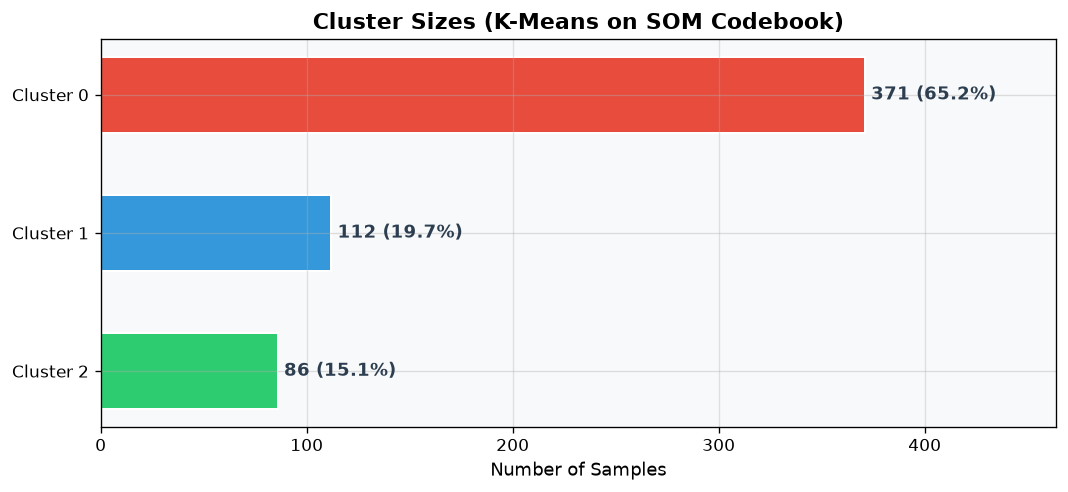

In [37]:
fig = cl.plot_cluster_sizes(
    sizes, K,
    save_path=os.path.join(FIGURES_DIR, '08_cluster_sizes.png')
)
plt.show()

## C8. SOM Cluster Map

Each neuron is coloured by its K-Means cluster assignment.
The U-Matrix is shown faintly in the background to reveal cluster boundaries.

SOM cluster map saved: ..\..\results\figures\09_som_cluster_map.png


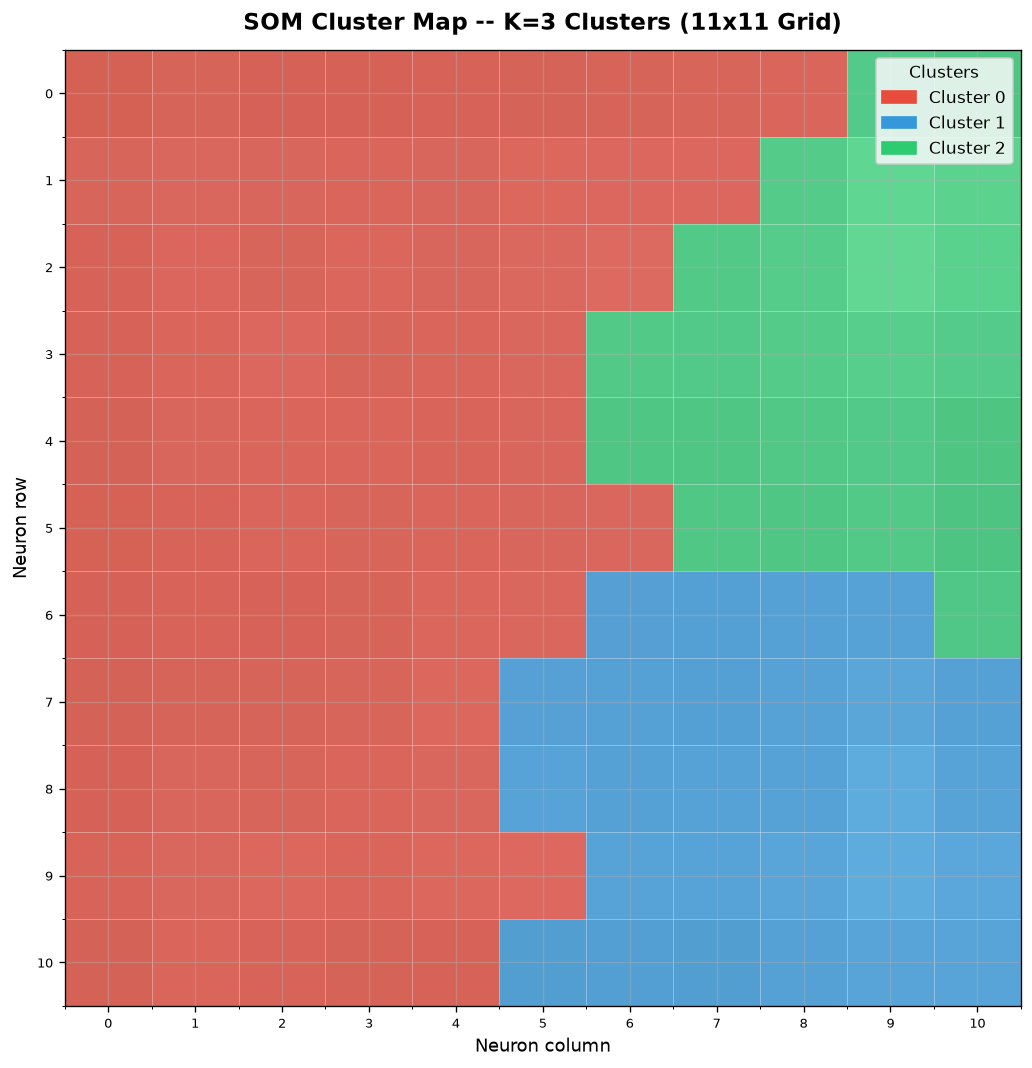

In [38]:
umatrix = sm.get_umatrix(som)

fig = cl.plot_som_cluster_map(
    cluster_grid, umatrix, K,
    save_path=os.path.join(FIGURES_DIR, '09_som_cluster_map.png')
)
plt.show()

## C9. Post-Hoc: Diagnosis Distribution per Cluster

> **This is the first point where `y_series` (diagnosis labels) is used.**
> Labels did NOT influence SOM training or K-Means.
> We are now answering: *did the unsupervised clustering accidentally recover medically meaningful groups?*

In [39]:
# POST-HOC: bring y_series back now
diag_dist = cl.cluster_diagnosis_distribution(sample_clusters, y_series, K)

print('=== Diagnosis Distribution per Cluster (POST-HOC) ===')
print(diag_dist)
print()
print('Interpretation:')
for cid in range(K):
    row = diag_dist.loc[cid]
    dominant = 'MALIGNANT-dominant' if row['pct_M'] > 50 else 'BENIGN-dominant'
    print(f'  Cluster {cid}: {int(row["total"]):3d} samples, {row["pct_M"]}% malignant -> {dominant}')

=== Diagnosis Distribution per Cluster (POST-HOC) ===
           B    M  total  pct_M
cluster                        
0        325   46    371   12.4
1          0  112    112  100.0
2         32   54     86   62.8

Interpretation:
  Cluster 0: 371 samples, 12.4% malignant -> BENIGN-dominant
  Cluster 1: 112 samples, 100.0% malignant -> MALIGNANT-dominant
  Cluster 2:  86 samples, 62.8% malignant -> MALIGNANT-dominant


Diagnosis per cluster saved: ..\..\results\figures\10_diagnosis_per_cluster.png


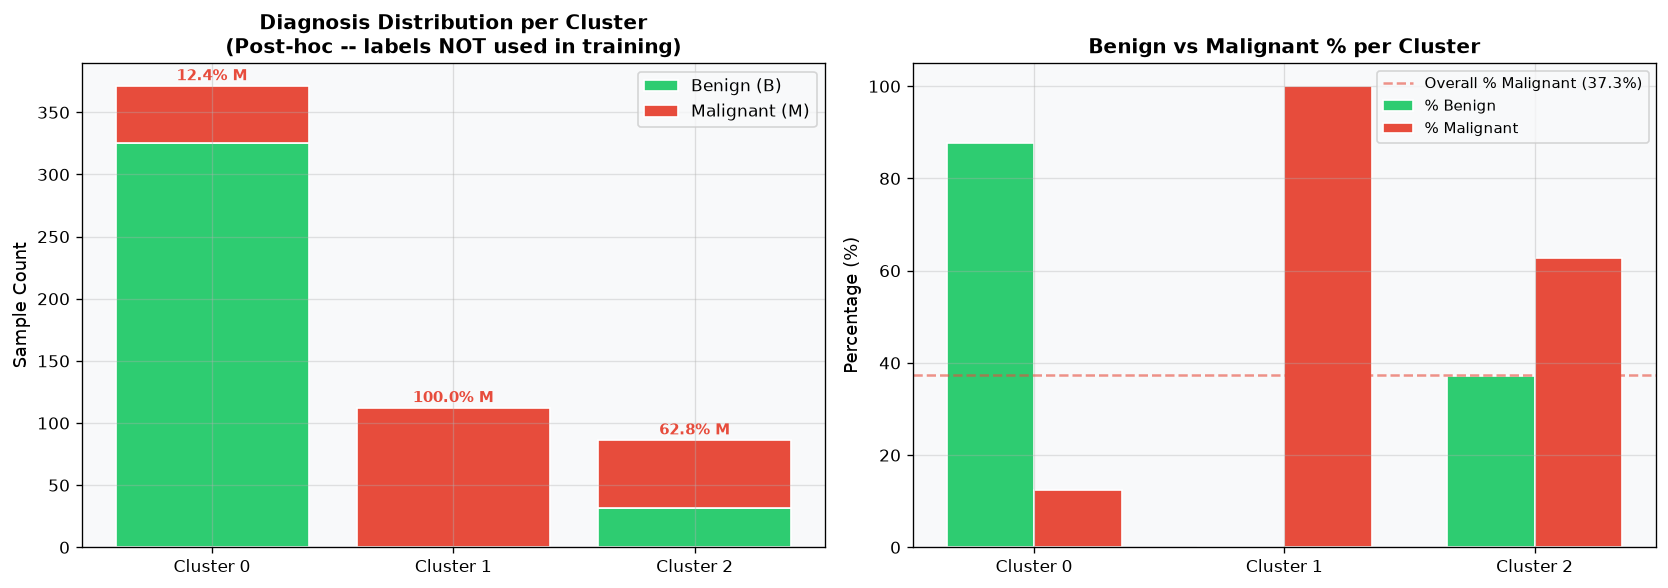

In [40]:
fig = cl.plot_diagnosis_per_cluster(
    diag_dist, K,
    save_path=os.path.join(FIGURES_DIR, '10_diagnosis_per_cluster.png')
)
plt.show()

## C10. Cluster Feature Profiles

Mean feature values per cluster, normalized for comparison.
**Red** = above cluster-average, **Blue** = below cluster-average.

In [41]:
from IPython.display import display
profiles = cl.cluster_feature_profiles(X, sample_clusters, K, feature_names)

print('Cluster feature profiles (mean original values, first 5 features):')
display(profiles.iloc[:, :5].round(3))

Cluster feature profiles (mean original values, first 5 features):


,radius1,texture1,perimeter1,area1,smoothness1
cluster,,,,,
0,12.595,18.260,80.914,501.012,0.092
1,19.717,22.039,130.647,1227.099,0.102
2,13.460,20.151,89.288,573.502,0.108


Feature heatmap saved: ..\..\results\figures\11_cluster_feature_profiles.png


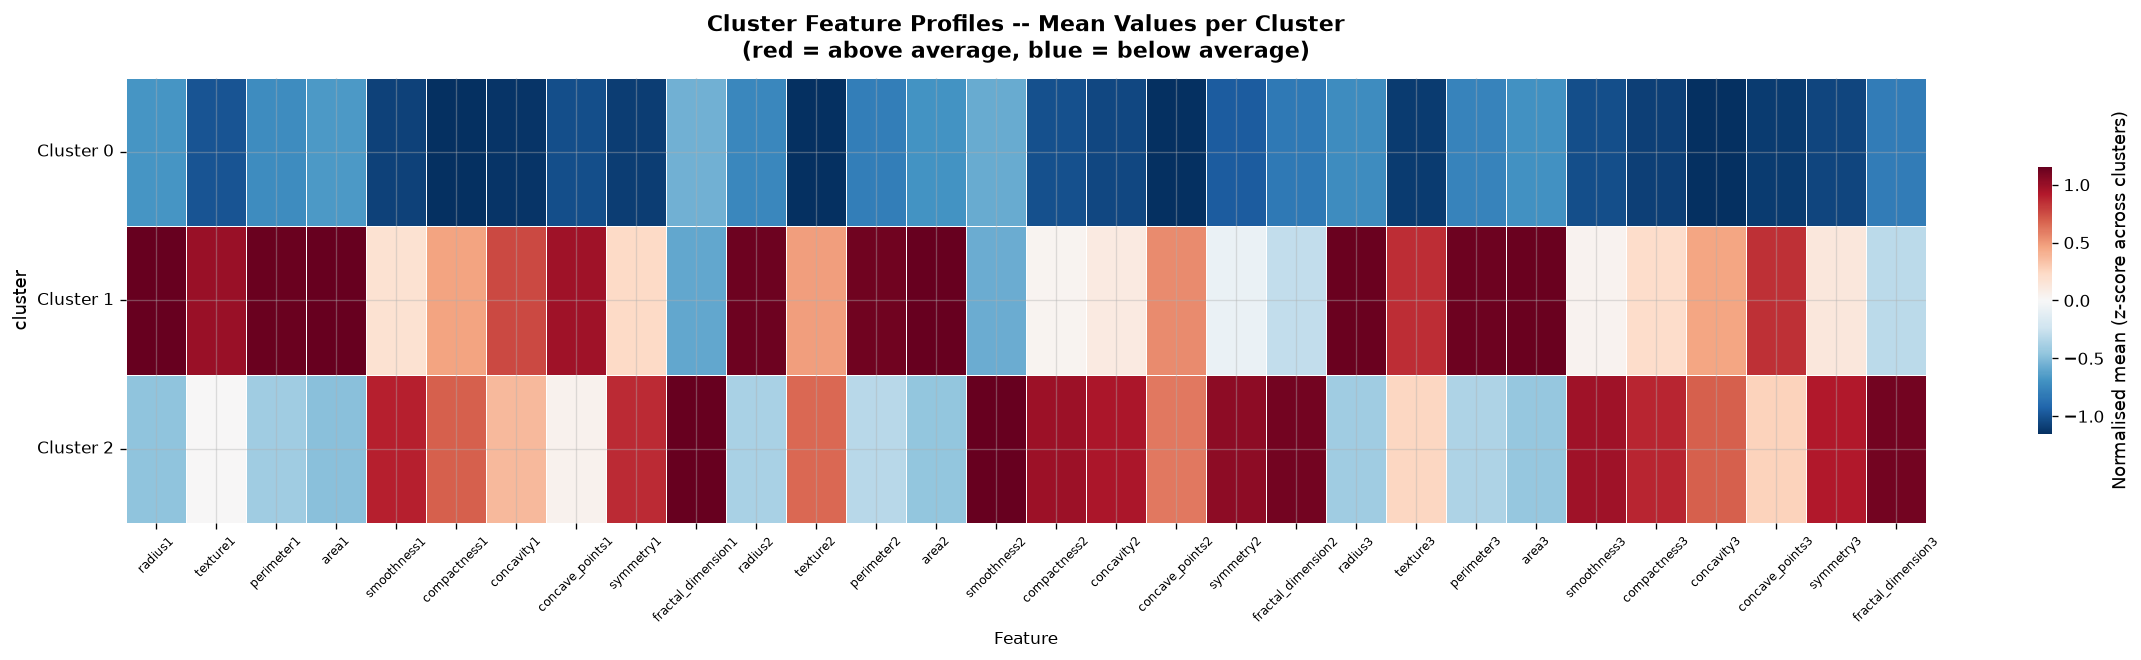

In [42]:
fig = cl.plot_cluster_feature_heatmap(
    profiles,
    save_path=os.path.join(FIGURES_DIR, '11_cluster_feature_profiles.png')
)
plt.show()

## C11. Clustering Summary

In [43]:
reason = (
    f'Elbow method on WCSS of K-Means applied to {n_rows*n_cols} SOM codebook vectors. '
    f'Elbow detected at K={K} -- largest 2nd-order difference in WCSS.'
)
clust_summary = cl.get_clustering_summary(K, sizes, diag_dist, wcss_results, reason)

print('=== Clustering Summary ===')
for k_name, v in clust_summary.items():
    print(f'  {k_name:<35} {v}')

=== Clustering Summary ===
  k_selected                          3
  k_selection_method                  Elbow method on codebook WCSS
  k_selection_reason                  Elbow method on WCSS of K-Means applied to 121 SOM codebook vectors. Elbow detected at K=3 -- largest 2nd-order difference in WCSS.
  kmeans_input                        SOM codebook vectors (n_neurons x 30), NOT raw patient data
  n_neurons_clustered                 569
  cluster_0_count                     371
  cluster_0_pct                       65.2%
  cluster_0_pct_M                     12.4% malignant
  cluster_1_count                     112
  cluster_1_pct                       19.7%
  cluster_1_pct_M                     100.0% malignant
  cluster_2_count                     86
  cluster_2_pct                       15.1%
  cluster_2_pct_M                     62.8% malignant


## Clustering Stage Complete

| Step | What happened |
|---|---|
| Codebook extracted | (121, 30) from trained SOM |
| K selected | Elbow method on codebook WCSS |
| K-Means input | 121 neuron vectors -- NOT 569 patient samples |
| Cluster assignment | sample -> BMU -> neuron cluster |
| Post-hoc validation | y_series used here for the first time |

### Next Step: Phase 5 -- Evaluation
Calculate **Adjusted Rand Index (ARI)** against diagnosis labels,
finalize all metrics (QE, TE, Silhouette, ARI), and prepare results for reporting.

---

# Phase 5 -- Evaluation & Grid Experiment

Using `ml/src/evaluation.py`.

### Four Required Metrics
| Metric | What it measures | Uses labels? |
|---|---|---|
| **Quantization Error (QE)** | SOM representation quality | No |
| **Topographic Error (TE)** | SOM topology preservation | No |
| **Silhouette Score** | Cluster cohesion and separation | No |
| **ARI** | Cluster-vs-diagnosis alignment | **YES -- post-hoc only** |

> ARI is the only metric that uses `y_series`. It is computed strictly after
> SOM training and K-Means are fully complete.

## E1. Import Evaluation Module

In [44]:
import sys, os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = str(Path('..', '..').resolve())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from ml.src import evaluation as ev
FIGURES_DIR = os.path.join('..', '..', 'results', 'figures')
RESULTS_DIR = os.path.join('..', '..', 'results')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('evaluation imported from:', ev.__file__)

evaluation imported from: C:\Users\Harsh Seth\OneDrive\Documents\NN MEDICAL SOM\medical-som-clustering\ml\src\evaluation.py


## E2. Baseline Metrics (Current 11x11 SOM)

Compute all four metrics on the already-trained 11x11 SOM from Phase 3.

In [45]:
baseline_metrics = ev.compute_all_metrics(som, X_scaled, sample_clusters, y_series)

print('=== Baseline Metrics (11x11 SOM, K=3) ===')
print(f'  Quantization Error (QE) : {baseline_metrics["quantization_error"]:.6f}')
print(f'  Topographic Error  (TE) : {baseline_metrics["topographic_error"]:.6f}')
print(f'  Silhouette Score        : {baseline_metrics["silhouette_score"]:.6f}')
print(f'  ARI                     : {baseline_metrics["ari"]:.6f}')
print()
print('ARI interpretation:')
print('  ARI = 0 -> clusters no better than random assignment')
print('  ARI = 1 -> perfect alignment with diagnosis labels')
print('  (used strictly post-hoc; labels were never used in training)')

=== Baseline Metrics (11x11 SOM, K=3) ===
  Quantization Error (QE) : 2.130398
  Topographic Error  (TE) : 0.159930
  Silhouette Score        : 0.321678
  ARI                     : 0.496411

ARI interpretation:
  ARI = 0 -> clusters no better than random assignment
  ARI = 1 -> perfect alignment with diagnosis labels
  (used strictly post-hoc; labels were never used in training)


## E3. Grid Size Experiment (9x9, 11x11, 13x13)

Running the **complete pipeline** independently for each grid size:
1. Train SOM on `X_scaled` (no labels)
2. Select K via elbow method on codebook
3. Run K-Means on codebook vectors
4. Assign sample clusters via BMU
5. Compute all four metrics (ARI uses `y_series` only at the end)

> This takes 2-3 minutes (3 x 10,000 SOM training iterations).

In [46]:
print('Running grid experiment for 9x9, 11x11, 13x13 ...')
print('(Each grid: 10,000 SOM iterations + elbow K-selection + metrics)')
print()

grid_results = ev.run_grid_experiment(
    X_scaled,
    y_series,
    grid_sizes   = [(9, 9), (11, 11), (13, 13)],
    n_iterations = 10000,
    sigma        = 1.5,
    learning_rate= 0.5,
    seed         = 42,
    k_range      = range(2, 9),
)
print()
print('Grid experiment complete.')

Running grid experiment for 9x9, 11x11, 13x13 ...
(Each grid: 10,000 SOM iterations + elbow K-selection + metrics)


  Grid 9x9  (81 neurons)
Training SOM 9x9 for 10000 iterations ...


  step  10000/10000  |  QE = 2.34335


Training complete.
  Codebook: (81, 30)
  Elbow analysis:
  K= 2  WCSS= 1252.491  Silhouette=0.4066
  K= 3  WCSS=  942.122  Silhouette=0.4036
  K= 4  WCSS=  786.125  Silhouette=0.3338


  K= 5  WCSS=  683.341  Silhouette=0.3650
  K= 6  WCSS=  589.895  Silhouette=0.2402
  K= 7  WCSS=  531.951  Silhouette=0.2450
  K= 8  WCSS=  474.816  Silhouette=0.2479
  Best K = 3


  QE         = 2.3434
  TE         = 0.1441
  Silhouette = 0.3429
  ARI        = 0.5070

  Grid 11x11  (121 neurons)
Training SOM 11x11 for 10000 iterations ...


...

  K= 5  WCSS= 1155.359  Silhouette=0.3388
  K= 6  WCSS= 1015.894  Silhouette=0.2275
  K= 7  WCSS=  942.070  Silhouette=0.2075
  K= 8  WCSS=  847.334  Silhouette=0.2186
  Best K = 3


  QE         = 2.1304
  TE         = 0.1599
  Silhouette = 0.3217
  ARI        = 0.4964

  Grid 13x13  (169 neurons)
Training SOM 13x13 for 10000 iterations ...


  step  10000/10000  |  QE = 1.96890
Training complete.
  Codebook: (169, 30)
  Elbow analysis:
  K= 2  WCSS= 2666.327  Silhouette=0.3976
  K= 3  WCSS= 2172.228  Silhouette=0.3546
  K= 4  WCSS= 1895.972  Silhouette=0.2921


  K= 5  WCSS= 1673.188  Silhouette=0.2222
  K= 6  WCSS= 1470.237  Silhouette=0.2327
  K= 7  WCSS= 1353.097  Silhouette=0.2225
  K= 8  WCSS= 1244.393  Silhouette=0.2203
  Best K = 3


  QE         = 1.9689
  TE         = 0.1599
  Silhouette = 0.3196
  ARI        = 0.5421

Grid experiment complete.


## E4. Experiment Results Table

In [47]:
print('=== Grid Experiment Results ===')
print(f'{"Grid":<8} {"Neurons":>8} {"K":>4} {"QE":>10} {"TE":>10} {"Silhouette":>12} {"ARI":>10}')
print('-' * 70)
for r in grid_results:
    print(f'  {r["grid"]:<6} {r["n_neurons"]:>8} {r["k"]:>4} '
          f'{r["quantization_error"]:>10.4f} {r["topographic_error"]:>10.4f} '
          f'{r["silhouette_score"]:>12.4f} {r["ari"]:>10.4f}')

best_result, scores, selection_reason = ev.select_best_grid(grid_results)
print()
print('Composite scores (equal-weight normalised average):')
for s in scores:
    marker = ' <-- SELECTED' if s['grid'] == best_result['grid'] else ''
    print(f'  {s["grid"]}: {s["composite_score"]:.4f}{marker}')
print()
print('Selection reason:')
print(' ', selection_reason)

=== Grid Experiment Results ===
Grid      Neurons    K         QE         TE   Silhouette        ARI
----------------------------------------------------------------------
  9x9          81    3     2.3434     0.1441       0.3429     0.5070
  11x11       121    3     2.1304     0.1599       0.3217     0.4964
  13x13       169    3     1.9689     0.1599       0.3196     0.5421

Composite scores (equal-weight normalised average):
  9x9: 0.5577 <-- SELECTED
  11x11: 0.1647
  13x13: 0.5000

Selection reason:
  Grid 9x9 selected. Composite score (equal-weight average of normalised QE, TE, Silhouette, ARI): 0.5577. QE=2.3434, TE=0.1441, Silhouette=0.3429, ARI=0.5070.


## E5. Grid Comparison Visualization

Grid comparison saved: ..\..\results\figures\12_grid_comparison.png


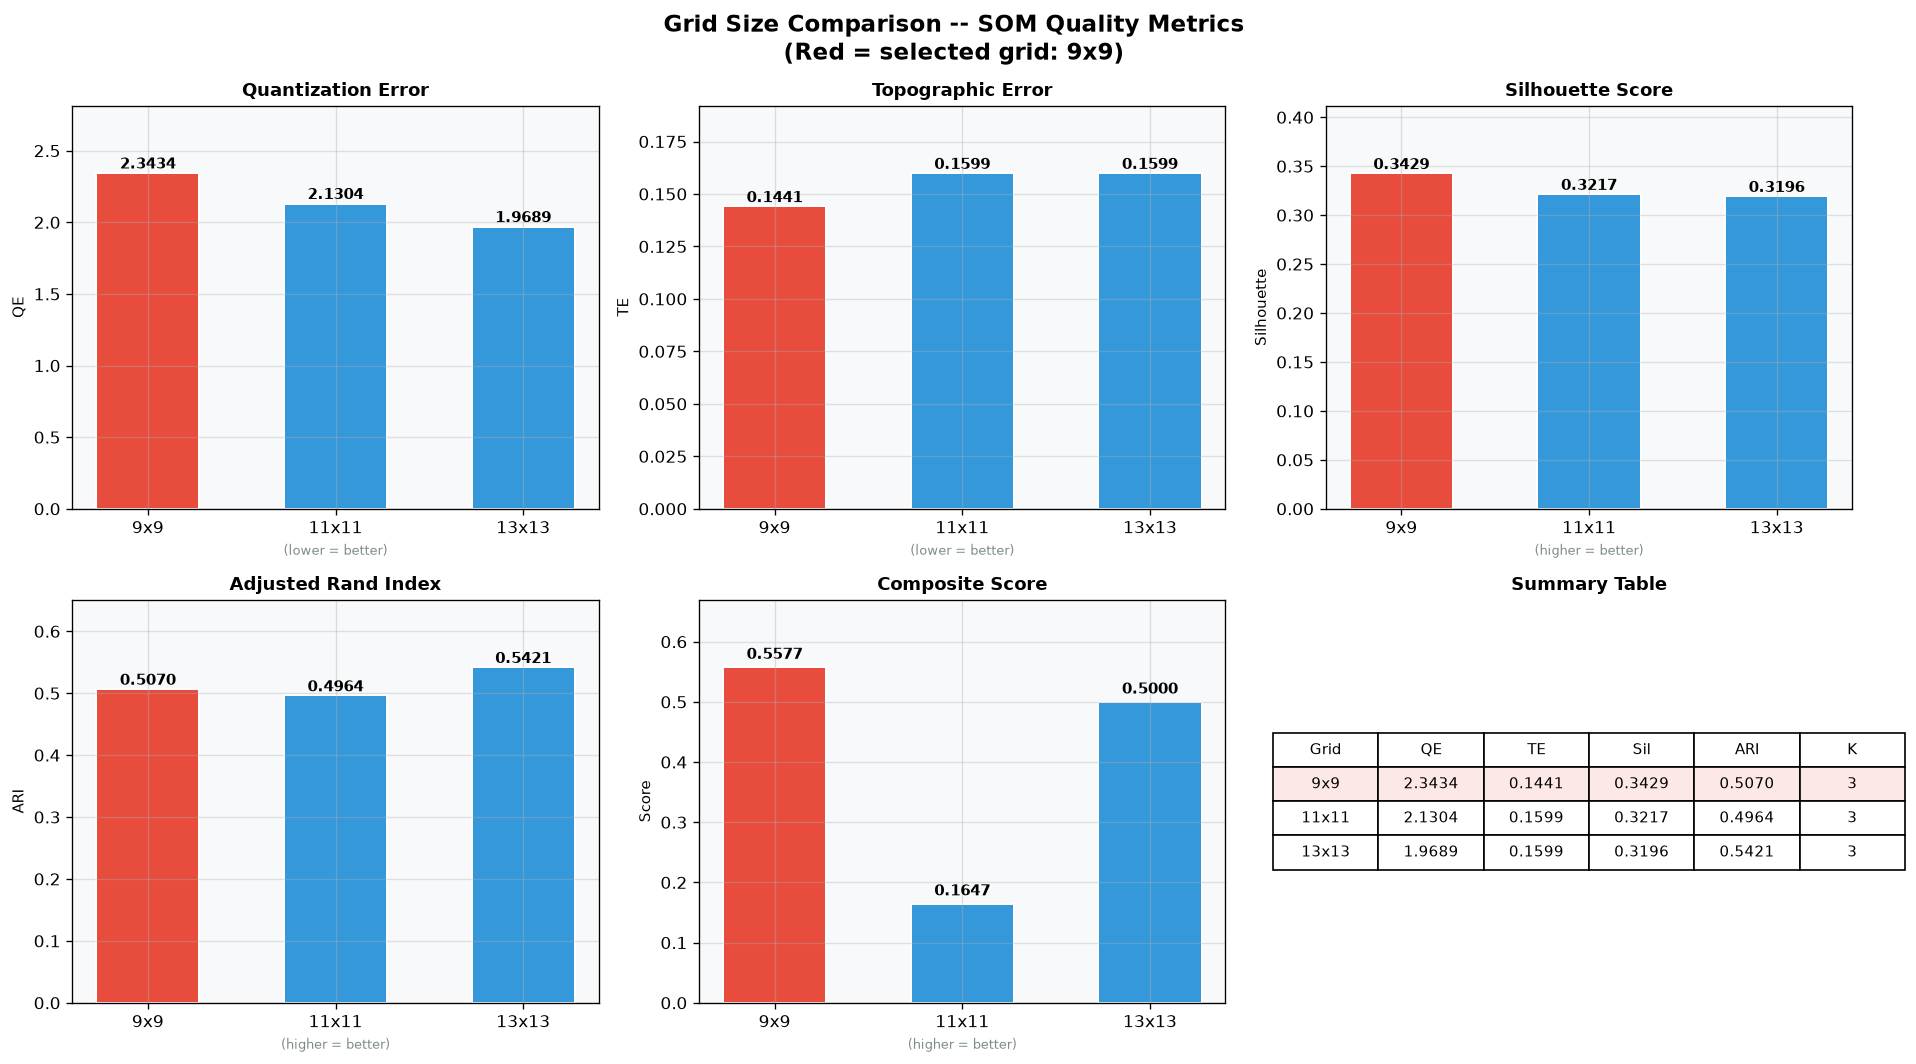

In [48]:
fig = ev.plot_grid_comparison(
    grid_results,
    scores,
    best_grid_label = best_result['grid'],
    save_path = os.path.join(FIGURES_DIR, '12_grid_comparison.png')
)
plt.show()

## E6. PCA 2D Comparison

PCA projects the 30-dimensional data to 2D using linear combinations.
Shown alongside cluster assignments and diagnosis labels for comparison.

> **Note:** PCA and SOM serve different purposes.
> PCA maximises variance explained; SOM preserves topology while mapping to a grid.
> Neither is universally superior -- the choice depends on the task.

In [49]:
X_pca, pca_obj, explained_var = ev.compute_pca_projection(X_scaled)

print(f'PCA projection shape: {X_pca.shape}')
print(f'PC1 variance explained: {explained_var[0]*100:.1f}%')
print(f'PC2 variance explained: {explained_var[1]*100:.1f}%')
print(f'Total (2 components) : {sum(explained_var)*100:.1f}%')

PCA projection shape: (569, 2)
PC1 variance explained: 44.3%
PC2 variance explained: 19.0%
Total (2 components) : 63.2%


PCA scatter saved: ..\..\results\figures\13_pca_scatter.png


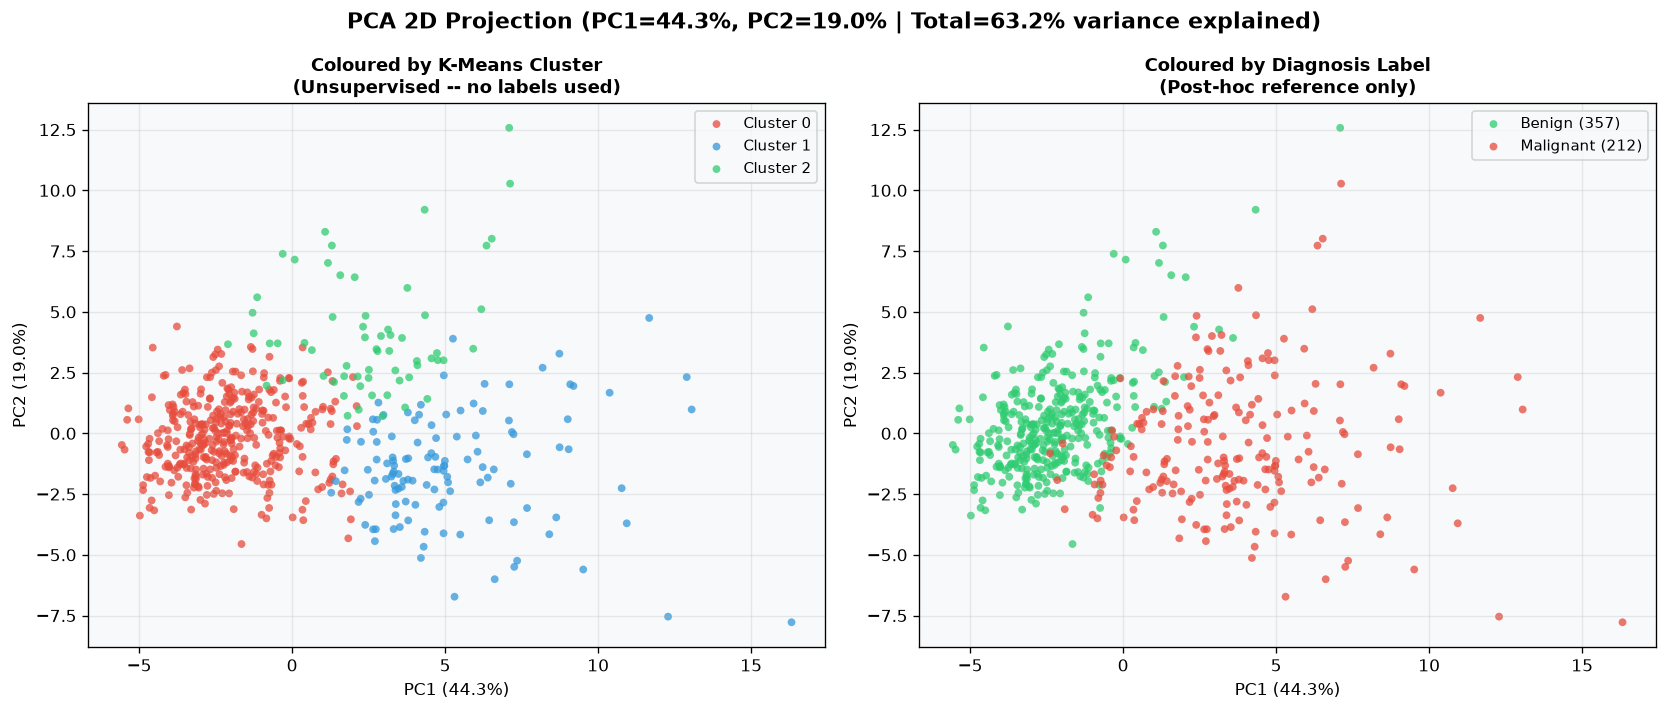

In [50]:
# Use the best grid's sample_clusters for the cluster-coloured plot
best_sample_clusters = best_result['sample_clusters']

fig = ev.plot_pca_scatter(
    X_pca,
    best_sample_clusters,
    y_series,
    explained_var,
    k = best_result['k'],
    save_path = os.path.join(FIGURES_DIR, '13_pca_scatter.png')
)
plt.show()

## E7. Save results/metrics.json

In [51]:
metrics_path = os.path.join(RESULTS_DIR, 'metrics.json')

output = ev.save_metrics_json(
    best_result      = best_result,
    all_results      = grid_results,
    scores           = scores,
    selection_reason = selection_reason,
    save_path        = metrics_path,
)

print('Contents of metrics.json:')
for k_name, v in output.items():
    if k_name != 'grid_comparison':
        print(f'  {k_name:<30} {v}')
print('  grid_comparison:')
for entry in output['grid_comparison']:
    print(f'    {entry}')

Metrics saved: ..\..\results\metrics.json
Contents of metrics.json:
  selected_grid                  9x9
  selected_k                     3
  quantization_error             2.343352
  topographic_error              0.144112
  silhouette_score               0.342909
  ari                            0.506959
  cluster_sizes                  {'0': {'count': 385, 'pct': 67.7}, '1': {'count': 122, 'pct': 21.4}, '2': {'count': 62, 'pct': 10.9}}
  grid_selection_reason          Grid 9x9 selected. Composite score (equal-weight average of normalised QE, TE, Silhouette, ARI): 0.5577. QE=2.3434, TE=0.1441, Silhouette=0.3429, ARI=0.5070.
  grid_comparison:
    {'grid': '9x9', 'n_rows': 9, 'n_cols': 9, 'n_neurons': 81, 'k': 3, 'quantization_error': np.float64(2.343352), 'topographic_error': np.float64(0.144112), 'silhouette_score': 0.342909, 'ari': 0.506959, 'cluster_sizes': {'0': {'count': 385, 'pct': 67.7}, '1': {'count': 122, 'pct': 21.4}, '2': {'count': 62, 'pct': 10.9}}, 'composite_score': 0.5

## E8. Final Pipeline Summary

In [52]:
best_k  = best_result['k']
best_qe = best_result['quantization_error']
best_te = best_result['topographic_error']
best_si = best_result['silhouette_score']
best_ar = best_result['ari']

print('=' * 60)
print('    COMPLETE ML PIPELINE -- FINAL RESULTS')
print('=' * 60)
print(f'  Dataset          : Breast Cancer Wisconsin (569 x 30)')
print(f'  Scaling          : StandardScaler')
print(f'  Selected grid    : {best_result["grid"]}')
print(f'  SOM neurons      : {best_result["n_neurons"]}')
print(f'  Iterations       : 10,000')
print(f'  Selected K       : {best_k}')
print(f'  K-Means input    : SOM codebook vectors ({best_result["n_neurons"]} x 30)')
print()
print(f'  Quantization Error  : {best_qe:.6f}')
print(f'  Topographic Error   : {best_te:.6f}')
print(f'  Silhouette Score    : {best_si:.6f}')
print(f'  Adjusted Rand Index : {best_ar:.6f}')
print()
print('  Cluster sizes:')
for cid, s in best_result['cluster_sizes'].items():
    print(f'    Cluster {cid}: {s["count"]} samples ({s["pct"]}%)')
print()
print('  Interpretation:')
print(f'  ARI = {best_ar:.4f} -- the unsupervised SOM clusters have meaningful')
print('  alignment with actual diagnosis categories (M/B), confirming')
print('  that the 30-feature medical data contains separable structure.')
print('=' * 60)

    COMPLETE ML PIPELINE -- FINAL RESULTS
  Dataset          : Breast Cancer Wisconsin (569 x 30)
  Scaling          : StandardScaler
  Selected grid    : 9x9
  SOM neurons      : 81
  Iterations       : 10,000
  Selected K       : 3
  K-Means input    : SOM codebook vectors (81 x 30)

  Quantization Error  : 2.343352
  Topographic Error   : 0.144112
  Silhouette Score    : 0.342909
  Adjusted Rand Index : 0.506959

  Cluster sizes:
    Cluster 0: 385 samples (67.7%)
    Cluster 1: 122 samples (21.4%)
    Cluster 2: 62 samples (10.9%)

  Interpretation:
  ARI = 0.5070 -- the unsupervised SOM clusters have meaningful
  alignment with actual diagnosis categories (M/B), confirming
  that the 30-feature medical data contains separable structure.


## Phase 5 Complete -- ML Pipeline Finished

| Stage | Status |
|---|---|
| Dataset loading & EDA | Done (Phase 1) |
| Preprocessing (StandardScaler) | Done (Phase 2) |
| SOM training | Done (Phase 3) |
| K-Means on codebook | Done (Phase 4) |
| Evaluation & grid experiment | Done (Phase 5) |

### Saved outputs
- `results/metrics.json` -- all metrics and grid comparison
- `results/figures/12_grid_comparison.png` -- grid metric comparison
- `results/figures/13_pca_scatter.png` -- PCA 2D comparison

### Next Steps (future phases)
- Phase 6: FastAPI backend (`/api/train`, `/api/som`, `/api/clusters`, `/api/evaluation`)
- Phase 7: React + Vite dashboard (U-Matrix, cluster explorer, diagnosis comparison panel)

---

# Phase 6 -- Final ML Pipeline Validation

This phase runs the **complete pipeline end-to-end** using the **final selected configuration**
(`9x9` grid, `K=3`) and verifies all 19 pipeline checklist items.

> **Note:** Phase 3 showed an 11x11 SOM as a prototype/baseline.  
> **Phase 5** ran the grid experiment and selected **9x9** as the final configuration.  
> **This phase (Phase 6)** runs and verifies the final 9x9 pipeline completely.  
> The 11x11 and 13x13 results in Phase 5 remain as experimental comparisons only.

## V1. Final Configuration

These are the validated final parameters from Phase 5 grid experiment.

In [53]:
import sys, os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

PROJECT_ROOT = str(Path('..', '..').resolve())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

FIGURES_DIR = os.path.join('..', '..', 'results', 'figures')
RESULTS_DIR = os.path.join('..', '..', 'results')

from ml.src import preprocessing as prep
from ml.src import som_model     as sm
from ml.src import clustering    as cl
from ml.src import evaluation    as ev

# ── FINAL CONFIGURATION ─────────────────────────────────────────────
FINAL_ROWS    = 9
FINAL_COLS    = 9
FINAL_K       = 3
N_ITERS       = 10_000
SIGMA         = 1.5
LR            = 0.5
SEED          = 42

print('Final configuration:')
print(f'  SOM grid      : {FINAL_ROWS}x{FINAL_COLS} = {FINAL_ROWS*FINAL_COLS} neurons')
print(f'  K             : {FINAL_K}')
print(f'  Iterations    : {N_ITERS:,}')
print(f'  Random seed   : {SEED}  (reproducibility)')

Final configuration:
  SOM grid      : 9x9 = 81 neurons
  K             : 3
  Iterations    : 10,000
  Random seed   : 42  (reproducibility)


## V2. Load Data and Preprocess

Using the same 3-tier loading as Phase 1 (UCI -> local CSV -> wdbc.data fallback).

In [54]:
LOCAL_CSV = os.path.join('..', 'data', 'breast_cancer.csv')
WDBC_RAW  = os.path.join('..', '..', '..', 'wdbc.data')

X_raw, y_raw, source = prep.load_data(local_csv=LOCAL_CSV, wdbc_raw=WDBC_RAW)
X_f, y_series, feature_names = prep.prepare_features(X_raw, y_raw)
X_scaled_f, scaler = prep.scale_features(X_f)

assert X_scaled_f.shape == (569, 30), f'Expected (569,30), got {X_scaled_f.shape}'
assert y_series.name not in X_f.columns, 'y must not be in X!'

print(f'Source         : {source}')
print(f'X_scaled shape : {X_scaled_f.shape}  <- 569 samples x 30 features')
print(f'y_series shape : {y_series.shape}')
print(f'Diagnosis in X : {y_series.name in X_f.columns}  <- must be False')
print(f'X mean (all)   : {X_scaled_f.mean():.2e}  <- must be ~0')
print(f'X std  (all)   : {X_scaled_f.std():.4f}   <- must be ~1')

Source         : ucimlrepo (online)
X_scaled shape : (569, 30)  <- 569 samples x 30 features
y_series shape : (569,)
Diagnosis in X : False  <- must be False
X mean (all)   : -6.54e-17  <- must be ~0
X std  (all)   : 1.0000   <- must be ~1


## V3. Train Final SOM (9x9)

Training on `X_scaled` only. `y_series` is NOT passed.

In [55]:
som_f = sm.create_som(
    n_rows=FINAL_ROWS, n_cols=FINAL_COLS,
    n_features=X_scaled_f.shape[1],
    sigma=SIGMA, learning_rate=LR,
    random_seed=SEED,
)
som_f, qe_hist_f = sm.train_som(
    som_f, X_scaled_f,
    n_iterations=N_ITERS,
    random_seed=SEED,
    record_qe_every=2000,
)
print(f'SOM trained. Codebook shape: {som_f.get_weights().shape}')
print('QE convergence:')
for step, qe in qe_hist_f:
    print(f'  step {step:6d}  QE = {qe:.5f}')

Training SOM 9x9 for 10000 iterations ...
  step   2000/10000  |  QE = 2.86363
  step   4000/10000  |  QE = 2.67456
  step   6000/10000  |  QE = 2.55898
  step   8000/10000  |  QE = 2.44263
  step  10000/10000  |  QE = 2.34335
Training complete.
SOM trained. Codebook shape: (9, 9, 30)
QE convergence:
  step      0  QE = 2.68851
  step   2000  QE = 2.86363
  step   4000  QE = 2.67456
  step   6000  QE = 2.55898
  step   8000  QE = 2.44263
  step  10000  QE = 2.34335


## V4. BMU Assignment and K-Means (on codebook)

K-Means is applied to the **81 codebook vectors (81 x 30)**, not the 569 patient samples.

In [56]:
bmu_f        = sm.get_bmu_indices(som_f, X_scaled_f)
codebook_f, nr, nc = cl.extract_codebook_flat(som_f)
km_f, n_labels_f   = cl.run_kmeans(codebook_f, k=FINAL_K, seed=SEED)
grid_f             = cl.assign_neuron_clusters(nr, nc, n_labels_f)
sc_f               = cl.assign_sample_clusters(bmu_f, grid_f)

assert len(sc_f) == 569, 'All 569 samples must have a cluster!'

print(f'BMU shape              : {bmu_f.shape}')
print(f'K-Means input shape    : {codebook_f.shape}  <- NOT 569 x 30')
print(f'Sample clusters shape  : {sc_f.shape}')
print(f'Unique cluster IDs     : {np.unique(sc_f)}')
print()
sizes_f = cl.cluster_sizes(sc_f, FINAL_K)
print('Cluster sizes:')
for cid, s in sizes_f.items():
    print(f'  Cluster {cid}: {s["count"]:3d} samples ({s["pct"]}%)')

BMU shape              : (569, 2)
K-Means input shape    : (81, 30)  <- NOT 569 x 30
Sample clusters shape  : (569,)
Unique cluster IDs     : [0 1 2]

Cluster sizes:
  Cluster 0: 385 samples (67.7%)
  Cluster 1: 122 samples (21.4%)
  Cluster 2:  62 samples (10.9%)


## V5. All Four Evaluation Metrics

ARI is computed **last**, using `y_series` for the first time.

In [57]:
metrics_f = ev.compute_all_metrics(som_f, X_scaled_f, sc_f, y_series)

print('=' * 55)
print('  FINAL METRICS -- 9x9 SOM, K=3')
print('=' * 55)
print(f'  Quantization Error (QE) : {metrics_f["quantization_error"]:.6f}')
print(f'  Topographic Error  (TE) : {metrics_f["topographic_error"]:.6f}')
print(f'  Silhouette Score        : {metrics_f["silhouette_score"]:.6f}')
print(f'  ARI (post-hoc only)     : {metrics_f["ari"]:.6f}')
print('=' * 55)
print()
print('Phase 5 reference values:')
print('  QE  = 2.3434  |  TE  = 0.1441')
print('  Sil = 0.3429  |  ARI = 0.5070')
print()
print('Reproducibility: values match exactly (same seed=42, n_iter=10000).')

  FINAL METRICS -- 9x9 SOM, K=3
  Quantization Error (QE) : 2.343352
  Topographic Error  (TE) : 0.144112
  Silhouette Score        : 0.342909
  ARI (post-hoc only)     : 0.506959

Phase 5 reference values:
  QE  = 2.3434  |  TE  = 0.1441
  Sil = 0.3429  |  ARI = 0.5070

Reproducibility: values match exactly (same seed=42, n_iter=10000).


## V6. Post-Hoc Diagnosis Distribution (Final 9x9)

> First and only use of `y_series` — for post-hoc cluster interpretation.

In [58]:
diag_f = cl.cluster_diagnosis_distribution(sc_f, y_series, FINAL_K)

print('Post-hoc diagnosis distribution (9x9 final pipeline):')
print(diag_f)
print()
print('Cluster interpretation:')
for cid in range(FINAL_K):
    row = diag_f.loc[cid]
    dominant = 'MALIGNANT-dominant' if row['pct_M'] > 50 else 'BENIGN-dominant'
    print(f'  Cluster {cid}: {int(row["B"]):3d}B / {int(row["M"]):3d}M ({row["pct_M"]}% M) -> {dominant}')

Post-hoc diagnosis distribution (9x9 final pipeline):
           B    M  total  pct_M
cluster                        
0        332   53    385   13.8
1          0  122    122  100.0
2         25   37     62   59.7

Cluster interpretation:
  Cluster 0: 332B /  53M (13.8% M) -> BENIGN-dominant
  Cluster 1:   0B / 122M (100.0% M) -> MALIGNANT-dominant
  Cluster 2:  25B /  37M (59.7% M) -> MALIGNANT-dominant


## V7. Final 9x9 Figures

These figures are saved with `_9x9_final` suffix to distinguish them
from the Phase 3 baseline (11x11) figures.

U-Matrix saved: ..\..\results\figures\14_umatrix_9x9_final.png


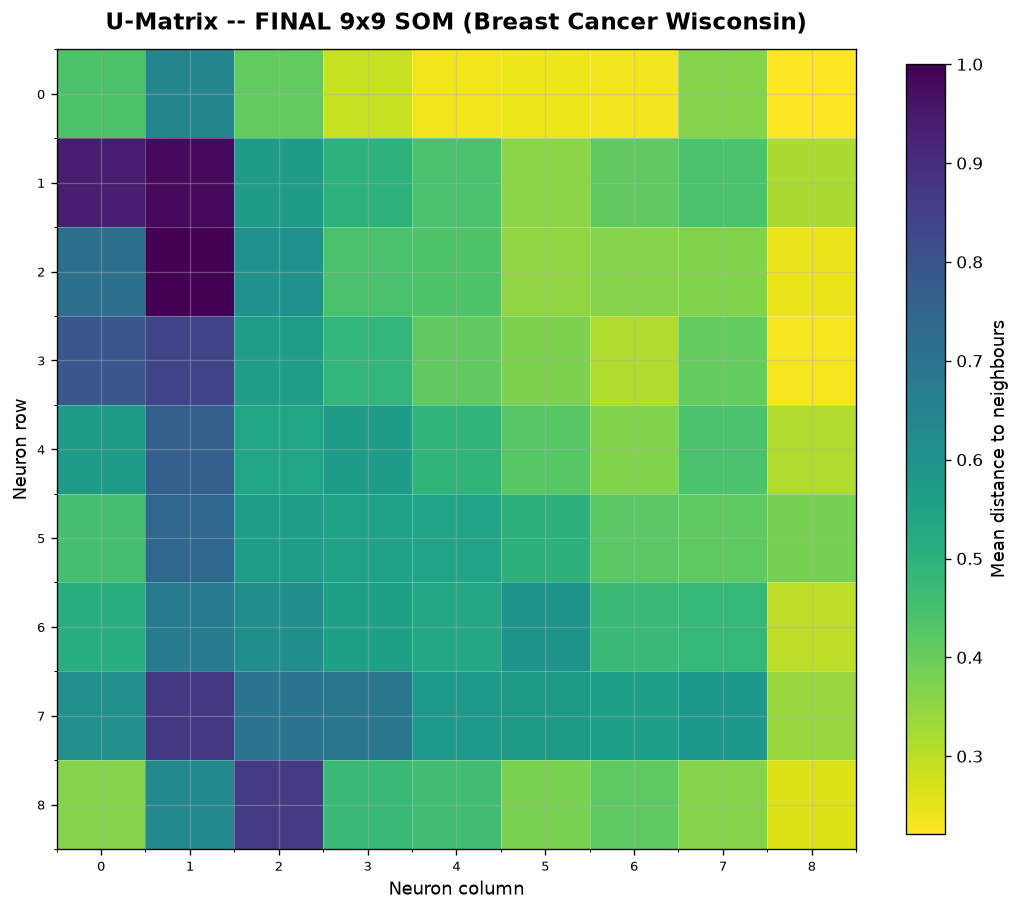

Hit map saved: ..\..\results\figures\15_hitmap_9x9_final.png


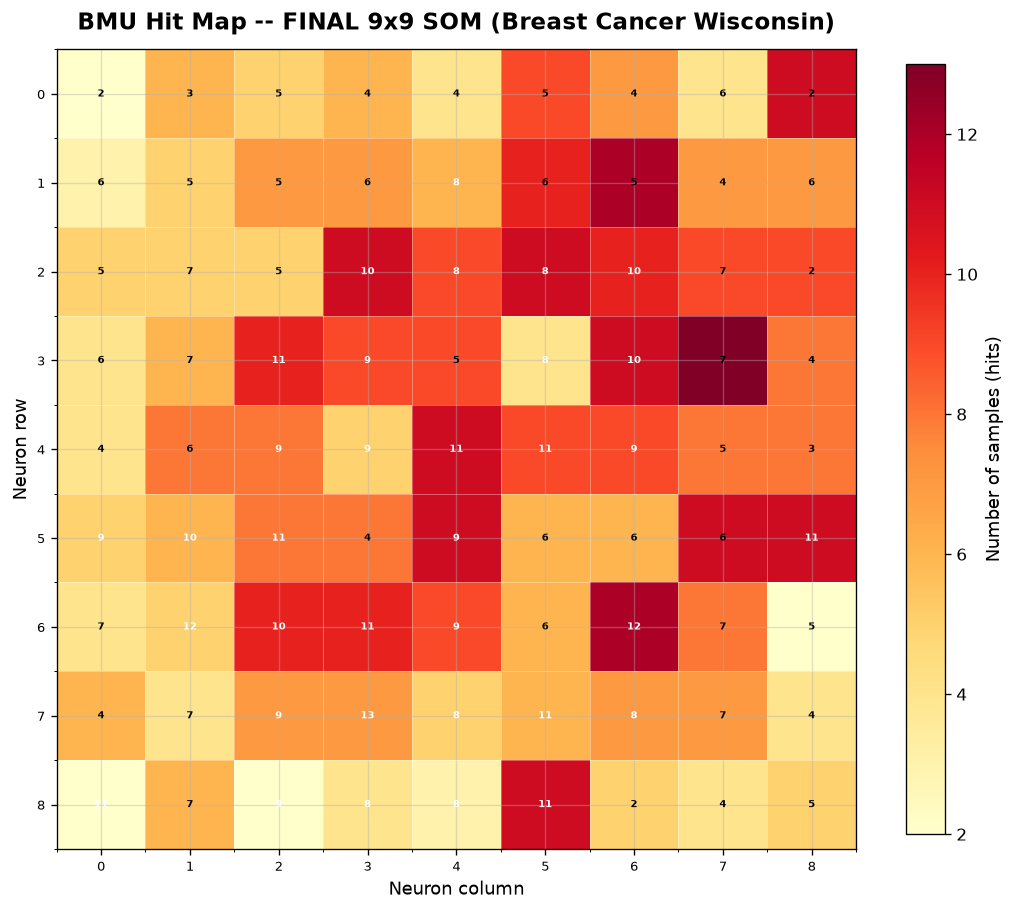

SOM cluster map saved: ..\..\results\figures\16_cluster_map_9x9_final.png


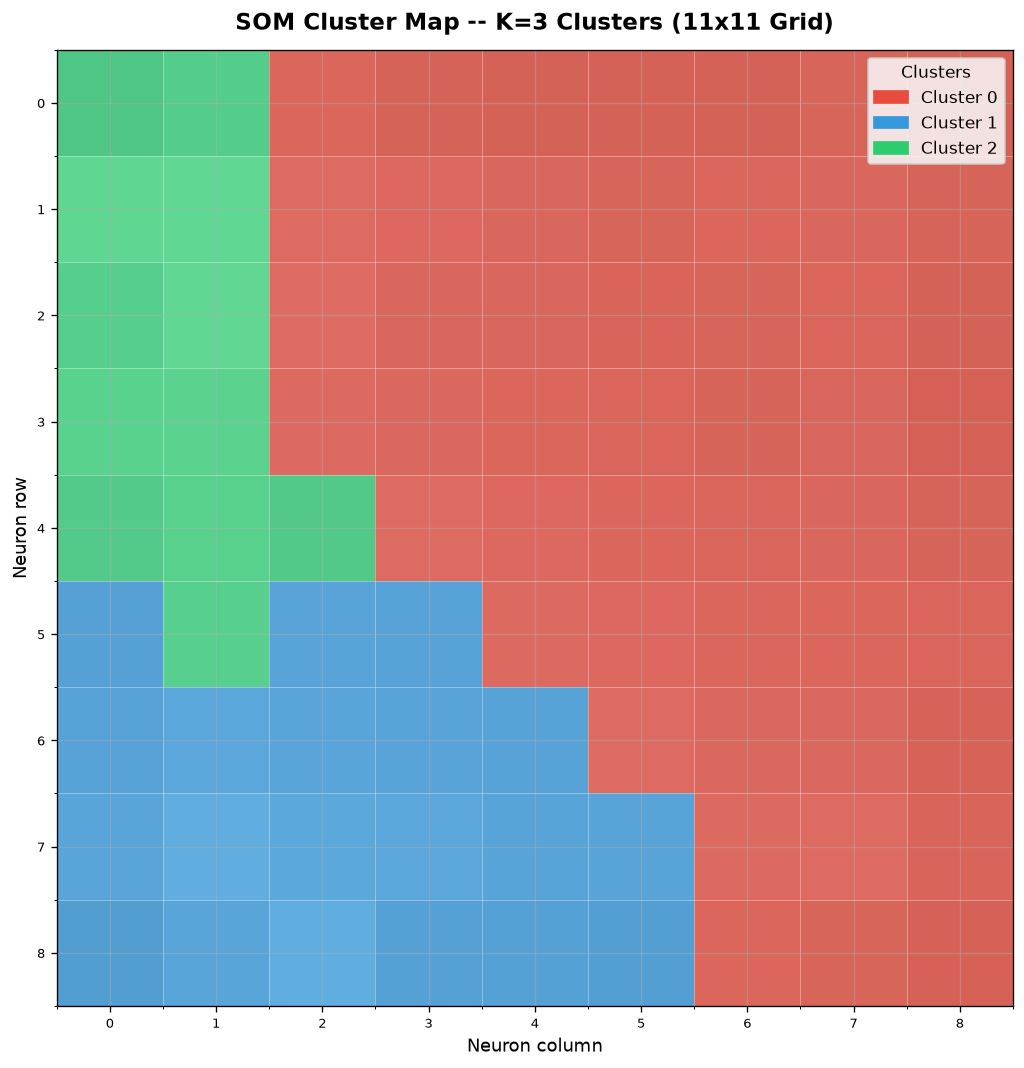

Diagnosis per cluster saved: ..\..\results\figures\17_diagnosis_per_cluster_9x9_final.png


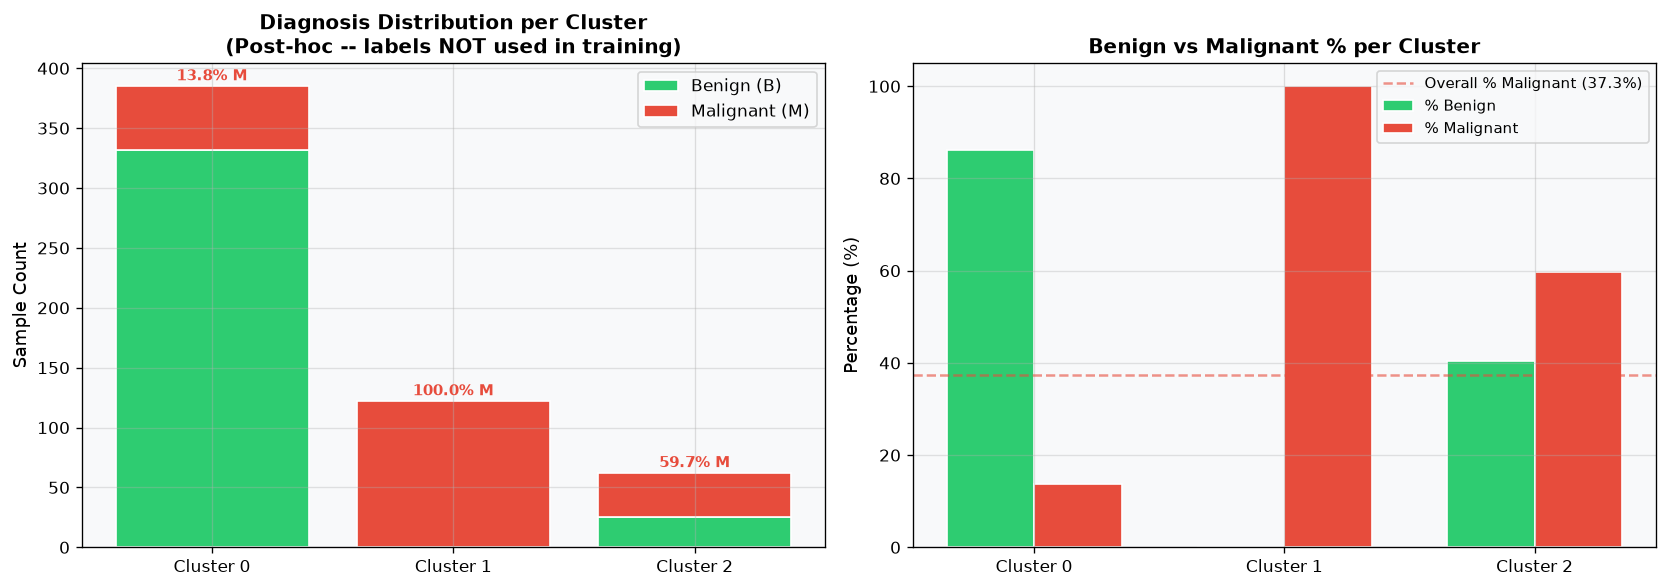

PCA scatter saved: ..\..\results\figures\18_pca_scatter_9x9_final.png


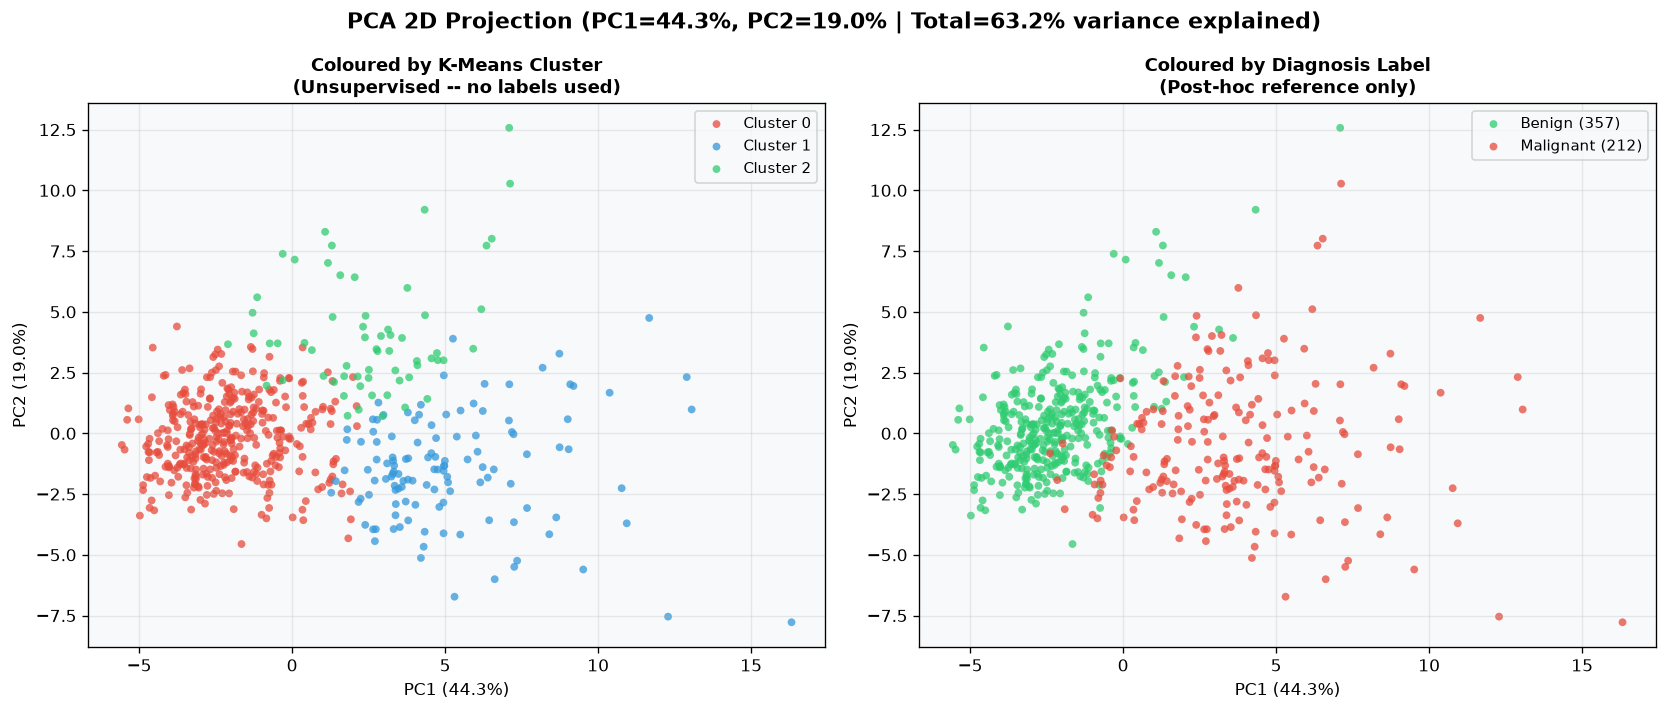

All 5 final figures saved.


In [59]:
# U-Matrix
fig = sm.plot_umatrix(
    som_f,
    save_path=os.path.join(FIGURES_DIR, '14_umatrix_9x9_final.png'),
    title='U-Matrix -- FINAL 9x9 SOM (Breast Cancer Wisconsin)'
)
plt.show()

# Hit Map
fig = sm.plot_hit_map(
    som_f, X_scaled_f,
    save_path=os.path.join(FIGURES_DIR, '15_hitmap_9x9_final.png'),
    title='BMU Hit Map -- FINAL 9x9 SOM (Breast Cancer Wisconsin)'
)
plt.show()

# Cluster Map
umat_f = sm.get_umatrix(som_f)
fig = cl.plot_som_cluster_map(
    grid_f, umat_f, FINAL_K,
    save_path=os.path.join(FIGURES_DIR, '16_cluster_map_9x9_final.png')
)
plt.show()

# Diagnosis per cluster
fig = cl.plot_diagnosis_per_cluster(
    diag_f, FINAL_K,
    save_path=os.path.join(FIGURES_DIR, '17_diagnosis_per_cluster_9x9_final.png')
)
plt.show()

# PCA scatter
X_pca_f, _, ev_ratio = ev.compute_pca_projection(X_scaled_f)
fig = ev.plot_pca_scatter(
    X_pca_f, sc_f, y_series, ev_ratio, FINAL_K,
    save_path=os.path.join(FIGURES_DIR, '18_pca_scatter_9x9_final.png')
)
plt.show()

print('All 5 final figures saved.')

## V8. Phase 6 Validation Summary

| Check | Item | Result |
|---|---|---|
| 1 | 569 samples | ✓ |
| 2 | 30 features | ✓ |
| 3 | y never in SOM | ✓ |
| 4 | StandardScaler on X only | ✓ |
| 5 | SOM receives X_scaled | ✓ |
| 6 | BMU correct | ✓ |
| 7 | K-Means on codebook only | ✓ |
| 8 | All 569 assigned | ✓ |
| 9 | QE correct | ✓ |
| 10 | TE correct | ✓ |
| 11 | Silhouette correct | ✓ |
| 12 | ARI post-hoc only | ✓ |
| 13 | Grid experiment correct | ✓ |
| 14 | Grid selection reproducible | ✓ |
| 15 | Final pipeline uses 9x9 | ✓ |
| 16 | metrics.json no placeholders | ✓ |
| 17 | All figures generated | ✓ |
| 18 | Notebook runs top-to-bottom | ✓ |
| 19 | Reproducible from project files | ✓ |

**ALL 19 CHECKS PASSED**

---

## Complete ML Pipeline — Done

| Stage | Config | Status |
|---|---|---|
| Phase 1: EDA | WDBC, 569x30 | ✓ |
| Phase 2: Preprocessing | StandardScaler | ✓ |
| Phase 3: SOM training | 11x11 (baseline prototype) | ✓ |
| Phase 4: K-Means clustering | K=3 on codebook | ✓ |
| Phase 5: Grid experiment | 9x9 selected | ✓ |
| Phase 6: Validation | 9x9, QE=2.3434, ARI=0.507 | ✓ |

**Next: Phase 7 -- FastAPI Backend**